# Trabalho Prático de Mineração de Dados — Fase 3
## Trabalho completo, solução final e comparação com uso de LLMs

**Disciplina:** Mineração de Dados  
**Grupo:** João Marcos Oliveira Neves (2024008644), Júlia Borba Fonseca de Souza (2023117580), Laura Martins Froede (2023087877), Matheus Soares dos Santos de Freitas (2024080043)  
**Dataset:** Adult Census Income  
**Tarefa de mineração:** Classificação
**Data da entrega:** 21/06/2026

---

## Objetivo deste notebook

Este notebook documenta a **Fase 3** do Trabalho Prático, isto é, a versão final consolidada da solução de mineração de dados.

Nesta fase, o grupo deve:

1. corrigir erros e limitações identificados na Fase 2;
2. consolidar a solução técnica efetivamente implementada;
3. executar a modelagem final;
4. avaliar criticamente os resultados;
5. comparar três elementos:
   - a solução sugerida pela LLM na condição **baseline**;
   - a solução sugerida pela LLM na condição **guiada por diretrizes de IA responsável**;
   - a solução final efetivamente implementada pelo grupo.

> **Importante:** este notebook é um modelo. Ele contém placeholders e trechos de código genéricos. O grupo deve adaptar tudo ao dataset, à tarefa e às decisões reais tomadas no trabalho.

# Como usar este notebook

Este notebook foi estruturado para orientar uma boa entrega final, sem substituir o trabalho do grupo.

Use os campos marcados como:

- `[INSERIR ...]`
- `[DESCREVER ...]`
- `[JUSTIFICAR ...]`
- `[ANALISAR ...]`
- `[PREENCHER ...]`

como indicações de conteúdo que deve ser produzido pelo grupo.

## Diferença em relação à Fase 2

Na Fase 2, o foco estava em documentar e comparar as interações com LLMs.

Na Fase 3, o foco passa a ser a **solução final consolidada**, isto é:

- quais sugestões da LLM foram incorporadas;
- quais foram corrigidas;
- quais foram rejeitadas;
- quais algoritmos e parâmetros foram realmente usados;
- quais resultados foram efetivamente obtidos;
- como os resultados se relacionam ao problema de negócio e às diretrizes de IA responsável.

Não é necessário repetir todos os links completos das conversas da Fase 2, mas a comparação entre baseline, guiada e solução final deve permanecer clara.

# 0. Controle da entrega e rastreabilidade

| Item | Valor |
|---|---|
| Nome do dataset | Adult Census Income |
| Link público do dataset | https://www.kaggle.com/datasets/uciml/adult-census-income |
| Número de linhas | 32.561 |
| Número de colunas | 15 |
| Tarefa de mineração | Classificação |
| Diretriz 1 de IA responsável | Justiça e Mitigação de Viés |
| Diretriz 2 de IA responsável | Explicabilidade |
| LLM usada na Fase 2 — baseline | Gemini Pro |
| LLM usada na Fase 2 — guiada | Gemini Pro |
| Notebook da Fase 2 | https://github.com/Doctor-Math/TPs-Mineracao-de-Dados/blob/VariableMath/notebooks/tp3/TP3_Fase2_Grupo6.ipynb |

## Resumo das decisões herdadas da Fase 2

A tabela abaixo consolida as diretrizes e escolhas técnicas herdadas da fase anterior, detalhando sua manutenção ou refinamento para a construção da solução final de mineração de dados.

| Decisão | Origem | Foi mantida na Fase 3? | Justificativa |
| --- | --- | --- | --- |
| **Utilização do XGBoost como classificador principal acompanhado de uma Árvore de Decisão como baseline.** | Grupo / Monitoria | **Sim** | Mantida para viabilizar a análise empírica do *trade-off* entre desempenho técnico ($AUC\text{-ROC}$ e $F1\text{-Score}$) e interpretabilidade nativa, conforme sugerido pela monitoria. |
| **Remoção das variáveis sensíveis (`sex`, `race`) e da proxy forte de gênero (`relationship`) do treinamento.** | Grupo | **Sim** | A decisão é mantida para proteger o algoritmo de aprender discriminações diretas. As colunas são preservadas exclusivamente no conjunto de auditoria para fins de monitoramento ético pós-hoc. |
| **Uso mandatório do framework SHAP (*TreeExplainer*) para auditoria de explicabilidade.** | Trilha B (Guiada) | **Sim** | Sendo o XGBoost um modelo caixa-preta, a análise pós-hoc via SHAP é indispensável para abrir a estrutura de decisões, validar a importância das variáveis e auditar o uso de *proxies* indiretas. |
| **Imposição de Restrições Monotônicas (*Monotonic Constraints*) nas variáveis de capital e educação.** | Trilha B (Guiada) | **Não** | Rejeitada em definitivo. O grupo avaliou que forçar comportamentos matemáticos rígidos antes do ajuste fino de hiperparâmetros introduziria pressupostos arbitrários, mascarando dinâmicas reais dos dados. |
| **Mapeamento de nulos (`?`) como `Unknown` e agrupamento de alta cardinalidade de `native-country`.** | Ambas (A e B) | **Sim** | A estratégia provou-se eficiente para reter o volume de instâncias de minorias geográficas sem induzir viés de seleção por descarte cego de dados faltantes. |
| **Otimização de hiperparâmetros por otimização cega de métrica global.** | Trilha A (Baseline) | **Parcialmente** | O grupo executará a tunagem fina (*GridSearchCV/RandomizedSearchCV*), mas o critério de seleção do melhor modelo não será apenas a performance global; ele será condicionado aos limites éticos de Impacto Díspar. |

In [1]:
# Configurações iniciais
# Esta célula centraliza imports, caminhos e parâmetros gerais do notebook.

import os
import time
import json
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Dataset Adult Census Income usado no TP3.
# O caminho local funciona no repositório; a função de carregamento abaixo também
# aceita URL caso o notebook seja executado fora do ambiente do projeto.
DATA_PATH = Path("data/data_tp3/adult.csv")

# Tipo de tarefa do TP.
TASK_TYPE = "classificacao"

# Coluna-alvo da classificação binária.
TARGET_COLUMN = "income"

# Atributos sensíveis monitorados nas análises de viés.
SENSITIVE_COLUMNS = ["sex", "race"]

# No Adult Income, valores ausentes aparecem como "?" no CSV original.
MISSING_VALUE_MARKERS = ["?"]

print("Configuração carregada.")
print(f"Tarefa definida: {TASK_TYPE}")
print(f"Coluna-alvo: {TARGET_COLUMN}")


Configuração carregada.
Tarefa definida: classificacao
Coluna-alvo: income


# 1. Business Understanding

Nesta seção, o grupo deve consolidar a compreensão do problema, incorporando eventuais correções feitas após a Fase 2.

A versão final deve responder:

1. Qual problema será investigado?
2. Por que o dataset é adequado para esse problema?
3. Qual tarefa de mineração de dados será executada?
4. Qual é o valor esperado da solução?
5. Quais diretrizes de IA responsável foram consideradas?
6. Como essas diretrizes influenciaram a solução final?
7. Quais limitações permanecem mesmo após a consolidação da solução?

## 1.1 Problema de negócio e objetivo analítico

Nesta seção, consolidamos a definição do problema de negócio e a formulação do objetivo analítico adotados para a solução final de mineração de dados, integrando as visões estratégica e técnica.

* **Contexto:** O desenvolvimento socioeconômico e a formulação de políticas assistenciais, estratégias de marketing direcionado e concessão de crédito dependem fortemente da capacidade de identificar o perfil demográfico, laboral e econômico da população. O censo demográfico fornece uma visão granular dessas características, permitindo entender como diferentes fatores se correlacionam com a renda dos indivíduos.
* **Problema:** A análise manual de grandes volumes de dados demográficos para triagem socioeconômica é ineficiente, custosa e propensa a erros. Além disso, os processos históricos de alocação de recursos e avaliação de perfis financeiros frequentemente absorvem e perpetuam preconceitos e disparidades estruturais (como lacunas salariais e de contratação entre gêneros e raças), gerando decisões corporativas ou públicas enviesadas se baseadas puramente em intuição.
* **Objetivo analítico:** Desenvolver e consolidar um modelo preditivo de classificação binária capaz de estimar, com alta estabilidade estatística e precisão de classe minoritária, se a renda anual de um indivíduo excede ou não o limiar de US$ 50.000 (`>50K` ou `<=50K`), utilizando atributos demográficos e profissionais legítimos. A solução deve quantificar e explicar a influência de cada variável nas predições individuais (Explicabilidade) e garantir que a taxa de falsos negativos e de seleção não prejudique desproporcionalmente subgrupos vulneráveis (Justiça e Mitigação de Viés).
* **Usuários ou interessados:** Analistas de formulação de políticas públicas de inclusão socioeconômica, comitês de governança corporativa e risco de instituições financeiras, cientistas de dados e órgãos reguladores interessados na auditoria de processos automatizados.
* **Decisões apoiadas:** Definição de critérios justos para a pré-aprovação de serviços financeiros, direcionamento de campanhas de captação de clientes de alta renda e desenho de programas públicos de redistribuição de renda ou capacitação profissional baseados em fatores de mérito e elegibilidade profissional.

---

### Ajustes em relação à Fase 2

O problema de negócio e a tarefa analítica principal foram **mantidos**, mas o escopo e o critério de sucesso foram **profundamente refinados e modificados** após as interações com as LLMs e os testes preliminares da Fase 2:

* **Mudança de Foco na Engenharia de Atributos:** Na Fase 2, o grupo identificou que a manutenção de variáveis como `relationship` (que indicava papéis familiares como *Husband* ou *Wife*) agia como uma *proxy* estatística devastadora que permitia ao modelo "reconstruir" implicitamente a variável sensível de gênero. Para a Fase 3, o escopo foi modificado para **excluir permanentemente** essa coluna do treinamento, forçando o modelo a se apoiar apenas em dados de carreira e capital (como `occupation` e `education.num`).
* **Refinamento das Métricas de Sucesso:** O objetivo analítico inicial visava apenas à otimização matemática das métricas globais ($AUC\text{-ROC}$ e $F1\text{-Score}$). Após constatarmos o Impacto Díspar severo (**0.3256** para mulheres) na fase anterior, o escopo da modelagem na Fase 3 foi ajustado para incluir **mecanismos de pós-processamento (alinhamento de limiar de decisão por subgrupo)**, mudando o foco da "otimização preditiva cega" para a busca por um ponto de equilíbrio estável entre desempenho econômico e equidade demográfica.
* **Inclusão de Baseline Prático:** Em conformidade com as discussões com a monitoria na fase anterior, o escopo analítico foi estendido para incluir formalmente a árvore de decisão como um contra-ponto de simplicidade operacional frente à complexidade do XGBoost.

## 1.2 Dataset, origem e características finais

### Identificação do dataset

- **Nome:** Adult Census Income
- **Fonte:** Kaggle
- **Link público:** https://www.kaggle.com/datasets/uciml/adult-census-income
- **Data de acesso ou download:** 06/06/2026

### Características gerais

| Aspecto | Descrição |
| --- | --- |
| **O que cada linha representa?** | Um indivíduo residente nos Estados Unidos que respondeu ao censo demográfico oficial no ano de 1994. |
| **O que cada coluna representa?** | Características sociodemográficas, socioeconômicas, de composição familiar e de histórico laboral do indivíduo. |
| **Número de instâncias** | 32.561 instâncias (registros no dataset original). |
| **Número de atributos** | 14 atributos preditivos + 1 variável-alvo (Total: 15 colunas). |
| **Tipos principais de atributos** | 6 atributos numéricos (contínuos/discretos) e 8 atributos categóricos nominais. Não há dados textuais livres ou temporais estritos. |
| **Existe variável-alvo?** | **SIM.** A variável `income`. É uma variável categórica binária que assume os valores `<=50K` (classe majoritária, ~76%) ou `>50K` (classe minoritária, ~24%), indicando se a renda anual do indivíduo supera US$ 50.000. |
| **Existem atributos sensíveis ou identificadores?** | **SIM.** Atributos sensíveis protegidos por lei: `sex` (gênero) e `race` (raça). Não existem identificadores únicos pessoais (como CPF/SSN ou nomes), garantindo o anonimato original das instâncias. |

---

### Dicionário de dados

A tabela abaixo detalha a estrutura final de dados e o papel exato que cada coluna desempenha na nossa solução consolidadada:

| Coluna | Tipo | Descrição | Papel na análise | Observações |
| --- | --- | --- | --- | --- |
| **age** | Numérico (Inteiro) | Idade do indivíduo. | **Feature** | Utilizada de forma contínua para capturar o impacto do tempo de carreira na renda. |
| **workclass** | Categórico | Tipo de setor ou regime de emprego (ex: Private, Self-emp, Federal-gov). | **Feature** | Valores omissos (`?`) foram mapeados e imputados como `Unknown`. |
| **fnlwgt** | Numérico (Contínuo) | Peso final amostral populacional atribuído pelo censo. | **Removida** | Descartada por não possuir correlação comportamental individual direta (induz ao overfitting). |
| **education** | Categórico | Grau mais alto de escolaridade formal alcançado em formato textual. | **Removida** | Descartada por redundância perfeita com a escala linear contida na variável `education.num`. |
| **education.num** | Numérico (Inteiro) | Tempo de escolaridade formal mapeado em uma escala ordinal numérica. | **Feature** | Atributo crucial para o modelo. Substitui a coluna categórica `education`. |
| **marital.status** | Categórico | Estado civil do indivíduo (ex: Married-civ-spouse, Never-married). | **Feature** | Preservada para capturar dinâmicas de estabilidade civil associadas à renda. |
| **occupation** | Categórico | Área profissional de atuação ou ocupação (ex: Exec-managerial, Craft-repair). | **Feature** | Categorias ausentes (`?`) imputadas como `Unknown`. Forte peso preditivo no modelo. |
| **relationship** | Categórico | Papel familiar do indivíduo dentro do domicílio (ex: Husband, Wife, Own-child). | **Removida** | **Removida por razões éticas.** Atuava como *proxy* forte de gênero (`sex`), burlando a restrição do treino. |
| **race** | Categórico | Classificação racial autodeclarada pelo indivíduo. | **Isolada p/ Auditoria** | **Removida do treinamento.** Preservada no dataframe paralelo para cálculo de Impacto Díspar. |
| **sex** | Categórico | Sexo biológico/gênero registrado do indivíduo. | **Isolada p/ Auditoria** | **Removida do treinamento.** Preservada no dataframe paralelo para cálculo de Impacto Díspar. |
| **capital.gain** | Numérico (Contínuo) | Ganhos de capital registrados (lucros de investimentos e ativos fora do salário). | **Feature** | Apresenta comportamento trivial (altos valores garantem predição positiva da classe `>50K`). |
| **capital.loss** | Numérico (Contínuo) | Perdas de capital registradas em transações financeiras externas. | **Feature** | Indica variação de patrimônio e investimentos do indivíduo. |
| **hours.per.week** | Numérico (Inteiro) | Carga horária semanal de trabalho dedicada ao emprego atual. | **Feature** | Variável contínua indicativa de intensidade laboral. |
| **native.country** | Categórico | País de origem nativo do indivíduo. | **Feature** | Cardinalidade agrupada pelo grupo nas categorias: `United-States`, `Other` e `Unknown`. |
| **income** | Categórico (Binário) | Indicador se a renda anual supera US$ 50.000. | **Alvo (Target)** | Mapeada de forma binária no código para `0` (`<=50K`) e `1` (`>50K`). |

## 1.3 Diretrizes de IA responsável e impacto na solução final

### Tabela de Diretrizes e Impactos Reais

| Diretriz | Pertinência ao problema | Como influenciou a solução final | Evidência concreta |
| --- | --- | --- | --- |
| **Justiça e Mitigação de Viés** | O dataset reflete o cenário socioeconômico de 1994, que carrega desigualdades estruturais históricas contra mulheres e minorias raciais. Otimizar o modelo sem essa diretriz automatizaria e perpetuaria a exclusão demográfica na previsão de renda. | Determinou o desenho de um pipeline de engenharia de dados com eliminação de *proxies* de atributos protegidos e alterou o critério de avaliação, que passou a exigir métricas de equidade demográfica pós-treino. | Remoção explícita da coluna `relationship` do conjunto de treinamento e inclusão das métricas `razao_taxa_predita` (Impacto Díspar) e `dif_recall_positiva` (Igualdade de Oportunidade) no código de validação. |
| **Explicabilidade** | O modelo de melhor desempenho técnico (**XGBoost**) baseia-se em um comitê complexo de árvores de decisão de gradiente aumentado, operando como uma caixa-preta. Para fins de auditoria e aplicação de negócios (como concessão de crédito), decisões automatizadas opacas são inaceitáveis. | Impôs o acoplamento mandatório de um framework de explicabilidade pós-hoc agnóstico à estrutura do modelo, permitindo abrir e justificar os pesos atribuídos aos recursos preditivos de forma global e local. | Implementação e execução do framework **SHAP** (`TreeExplainer`) no pipeline de avaliação final, gerando os plots de importância global e gráficos de enxame (*beeswarm*) para auditar o comportamento do algoritmo. |

---

### Análise

A incorporação explícita de diretrizes de IA Responsável deixou de ser um mero exercício teórico e passou a ditar ativamente a engenharia da nossa solução de mineração de dados, alterando os fundamentos e os critérios de validação do projeto.

#### 1. Alterações Estruturais no Pipeline (Preparação, Modelagem e Avaliação)

As diretrizes provocaram mudanças severas em todas as etapas do ciclo CRISP-DM:

* **Na Preparação de Dados:** Rompeu-se com o mito da "justiça por cegueira". Compreendeu-se que retirar `sex` e `race` do conjunto de treino era insuficiente. A diretriz de Justiça exigiu uma investigação de correlações que levou à detecção e **exclusão da variável `relationship**`, impedindo que o modelo decodificasse indiretamente o gênero dos indivíduos por meio do papel familiar (*Husband*/*Wife*).
* **Na Modelagem:** Forçou-se o abandono da busca por um algoritmo único. Adotou-se uma arquitetura de avaliação dual, inserindo uma Árvore de Decisão simples como *baseline* interpretável em paralelo ao XGBoost, estabelecendo uma régua de comparação clara para o aumento de complexidade.
* **Na Avaliação:** O sucesso do projeto foi completamente redefinido. Um modelo com alta $AUC\text{-ROC}$ global não é mais considerado "aprovado" se violar as restrições éticas de subgrupo. A inclusão das tabelas `metricas_subgrupo` e `resumo_disparidades` blindou a avaliação contra o autoengano das métricas agregadas.

#### 2. Justificativa Técnica das Alterações

Todas as mudanças encontram amparo no rigor da Ciência de Dados. A remoção de `relationship` foi justificada estatisticamente para mitigar a colinearidade velada com o atributo sensível `sex`. A inclusão do SHAP baseia-se na teoria dos Jogos Cooperativos (Valores de Shapley), garantindo uma distribuição justa e matematicamente consistente da atribuição de importância de cada recurso para a predição final do XGBoost, superando as limitações do método nativo de ganho de pureza (*feature importance* clássico), que tende a inflar variáveis contínuas com alta cardinalidade.

#### 3. Trade-offs entre Responsabilidade e Desempenho Técnico

O experimento preliminar escancarou o *trade-off* mais clássico da área: **Interpretabilidade Nativa × Desempenho Estatístico**. A Árvore de Decisão entregou o maior nível de transparência lógica e baixo custo, porém sua Precisão na classe positiva foi de pífios **0.4884** (inviável para o negócio). O XGBoost elevou a capacidade preditiva de alta renda para **0.5938** de Precisão e **0.9082** de $AUC\text{-ROC}$, mas trouxe consigo a total opacidade.

O grupo resolveu esse impasse adotando a complexidade do XGBoost, mas arcando com o "custo de governança" de desenvolver, otimizar e documentar a explicabilidade pós-hoc via SHAP. Além disso, o teste revelou um *trade-off* amargo entre **Justiça Demográfica e Realidade dos Dados**: o XGBoost atingiu paridade de oportunidade no erro (diferença de recall de quase zero, **0.0024**), mas manteve um Impacto Díspar severo de **0.3256**. Isso provou que mitigar o viés em dados estruturalmente desiguais de 1994 exige aceitar uma possível redução na performance global se decidirmos forçar o alinhamento artificial de limiares (*threshold shifting*) na Fase 3.

#### 4. Diretrizes Pouco Aplicáveis ou Rejeitadas

A diretriz de **Privacidade**, embora de extrema importância conceitual, demonstrou baixa aplicabilidade prática em termos de alterações diretas no pipeline técnico nesta fase do projeto. Como o dataset *Adult Census Income* é uma base pública, histórica, de domínio aberto e totalmente anonimizada na origem (sem nomes, documentos ou identificadores PII), não houve necessidade de implementar técnicas complexas como Privacidade Diferencial ou criptografia homomórfica no código. A governança de dados limitou-se a garantir a segurança e integridade do armazenamento e reprodutibilidade do notebook.

# 2. Data Understanding & Data Preparation

Nesta seção, o grupo deve apresentar a versão final da exploração e preparação dos dados.

A preparação final deve estar alinhada à tarefa de mineração e deve incorporar correções ou melhorias identificadas na Fase 2.

A seção deve incluir:

- carregamento do dataset;
- validação das restrições mínimas;
- análise de tipos, nulos, duplicatas e inconsistências;
- análise visual;
- decisões finais de limpeza e transformação;
- preparação específica para a tarefa;
- justificativa das escolhas.

In [2]:
# Carregamento do dataset
# Adapte esta célula ao formato real: CSV, XLSX, JSON, Parquet etc.

from pathlib import Path
import pandas as pd


def resolver_caminho_dataset(caminho):
    """Resolve o caminho do dataset tanto a partir da raiz do repo quanto da pasta do notebook."""
    caminho = Path(caminho) if not str(caminho).startswith(("http://", "https://")) else caminho

    if isinstance(caminho, str):
        return caminho

    candidatos = [
        caminho,
        Path.cwd() / caminho,
        Path.cwd().parent.parent / caminho,
    ]

    for candidato in candidatos:
        if candidato.exists():
            return candidato

    raise FileNotFoundError(f"Arquivo local não encontrado. Caminhos testados: {candidatos}")


def carregar_dataset(caminho, missing_values=None) -> pd.DataFrame:
    """Carrega o dataset Adult Income a partir de um caminho local ou URL CSV."""
    missing_values = missing_values or []

    if str(caminho).startswith(("http://", "https://")):
        return pd.read_csv(caminho, na_values=missing_values)

    caminho_resolvido = resolver_caminho_dataset(caminho)

    if Path(caminho_resolvido).suffix.lower() != ".csv":
        raise ValueError("Formato não tratado neste notebook. Esperado um arquivo .csv.")

    return pd.read_csv(caminho_resolvido, na_values=missing_values)


df = carregar_dataset(DATA_PATH, missing_values=MISSING_VALUE_MARKERS)

print("Dataset carregado com sucesso!")
print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")
print(f"Coluna-alvo: {TARGET_COLUMN}")
display(df.head())

Dataset carregado com sucesso!
Número de linhas: 32561
Número de colunas: 15
Coluna-alvo: income


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
# Validação das restrições mínimas da especificação
# A especificação exige dataset publicamente acessível, com pelo menos 1000 linhas e 4 colunas.
# O link público deve ser documentado no texto; aqui validamos apenas dimensões.

def verificar_restricoes_dataset(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        print("Dataset não carregado.")
        return pd.DataFrame()

    n_linhas, n_colunas = df.shape

    validacao = pd.DataFrame([
        {
            "criterio": "Mínimo de 1000 linhas",
            "valor_observado": n_linhas,
            "atende": n_linhas >= 1000
        },
        {
            "criterio": "Mínimo de 4 colunas",
            "valor_observado": n_colunas,
            "atende": n_colunas >= 4
        },
        {
            "criterio": "Dataset publicamente acessível",
            "valor_observado": "https://www.kaggle.com/datasets/uciml/adult-census-income",
            "atende": "True"
        }
    ])

    return validacao

# Exemplo de uso:
display(verificar_restricoes_dataset(df))

,criterio,valor_observado,atende
0,Mínimo de 1000 linhas,32561,True
1,Mínimo de 4 colunas,15,True
2,Dataset publicamente acessível,https://www.kaggle.com/datasets/uciml/adult-ce...,True


In [4]:
# Resumo estrutural do dataset

def resumo_estrutural(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        print("Dataset não carregado.")
        return pd.DataFrame()

    resumo = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "perc_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(dropna=True),
        "exemplo_valor": df.apply(lambda col: col.dropna().iloc[0] if col.dropna().shape[0] > 0 else np.nan)
    })

    return resumo.sort_values(by=["perc_nulos", "n_unicos"], ascending=[False, False])

# Exemplo de uso:
resumo = resumo_estrutural(df)
display(resumo)

,tipo,n_nulos,perc_nulos,n_unicos,exemplo_valor
occupation,object,1843,5.66,14,Exec-managerial
workclass,object,1836,5.64,8,Private
native.country,object,583,1.79,41,United-States
fnlwgt,int64,0,0.00,21648,77053
capital.gain,int64,0,0.00,119,0
hours.per.week,int64,0,0.00,94,40
capital.loss,int64,0,0.00,92,4356
age,int64,0,0.00,73,90
education,object,0,0.00,16,HS-grad
education.num,int64,0,0.00,16,9


## 2.1 Interpretação da exploração inicial

Com base na execução dos scripts de diagnóstico e na consolidação dos metadados da base, realizamos uma leitura crítica do comportamento inicial do dataset *Adult Census Income*.

### Análise Estrutural e Estatística da Base

* **Quantidade de Linhas e Colunas:** O dataset conta com exatamente **32.561 linhas** (instâncias) e **15 colunas** (atributos). O script de validação de restrições mínimas confirmou o atendimento das exigências da disciplina de forma integral (`True` para número mínimo de linhas e colunas).
* **Tipos de Variáveis:** A base apresenta uma composição mista bem distribuída. Temos variáveis numéricas do tipo inteiro e contínuo (`age`, `fnlwgt`, `education.num`, `capital.gain`, `capital.loss` e `hours.per.week`) e atributos qualitativos categóricos representados como objetos textuais (`workclass`, `education`, `marital.status`, `occupation`, `relationship`, `race`, `sex` e `native.country`).
* **Valores Ausentes:** A análise detalhada identificou que os dados omissos estavam originalmente codificados com o caractere `?` na base bruta. Ao mapeá-los, detectou-se que três atributos concentram falhas de preenchimento: `occupation` possui **1.843 valores nulos (5,66%)**, `workclass` apresenta **1.836 nulos (5,64%)** e `native.country` registra **583 nulos (1,79%)**. Todas as demais variáveis possuem 100% de preenchimento.
* **Duplicatas:** Foram detectados registros duplicados residuais resultantes da coleta censitária (indivíduos com características socioeconômicas idênticas na amostragem), os quais passam por tratamento de limpeza e deduplicação para evitar vazamento ou sobrepeso artificial no treinamento.
* **Colunas com Alta Cardinalidade:** O atributo `native.country` destaca-se negativamente pela altíssima cardinalidade, contendo **41 valores únicos**. A dispersão de registros entre dezenas de países de origem cria subgrupos com baixíssima representatividade amostral, o que exige um agrupamento estratégico pelo grupo.
* **Possíveis Identificadores:** Não foram identificadas variáveis que funcionem como chaves primárias ou identificadores únicos diretos (como nomes, IDs cadastrais ou SSN). A coluna `fnlwgt` (peso final amostral) simula uma quase-chave pela alta dispersão (**21.648 valores únicos**), mas trata-se de um cálculo populacional ponderado do censo, e não de um identificador individual.
* **Possíveis Atributos Sensíveis:** Estão explicitamente presentes dois atributos protegidos: `sex` (binário: *Female* e *Male*) e `race` (politômico com 5 categorias: *White*, *Black*, *Asian-Pac-Islander*, *Amer-Indian-Eskimo* e *Other*).
* **Atributos Relevantes para a Tarefa:** Variáveis ligadas diretamente a capital e trabalho mostram-se cruciais na exploração visual. `capital.gain`, `capital.loss`, `hours.per.week` e a escala de escolaridade `education.num` apresentam alta variância e forte correlação empírica com a variação da classe-alvo `income`.

---

### Limitações Percebidas e Riscos Diagnósticos

A exploração inicial expôs assimetrias estruturais severas que limitam e enviesam o aprendizado se os modelos forem otimizados de forma puramente matemática:

1. **Desbalanceamento Crítico da Classe-Alvo:** O dataset é altamente desequilibrado. A classe de alta renda (`>50K`) atua como classe minoritária, enquanto a classe de baixa renda (`<=50K`) domina a base. Isso justifica a decisão do grupo de adotar o parâmetro `scale_pos_weight = 3.151` no XGBoost para penalizar proporcionalmente os erros de classificação na classe minoritária.
2. **Assimetria Amostral nos Atributos Sensíveis:** A base possui uma severa desigualdade na quantidade de instâncias por gênero e raça. No recorte de gênero, a base conta com **4.335 homens contra apenas 2.173 mulheres**. No recorte racial, o grupo `White` dita a composição com **5.581 instâncias**, enquanto minorias como `Amer-Indian-Eskimo` possuem uma amostragem ínfima de apenas **53 indivíduos**. Modelos expostos a essa desproporção tendem a ignorar o padrão de comportamento de grupos sub-representados.
3. **O Fenômeno das Proxies Ocultas:** A variável `relationship` possui comportamento colinear perfeito em subgrupos específicos (como a relação intrínseca entre os rótulos *Husband* e o sexo masculino). Manter esse atributo anularia o propósito de isolar as variáveis sensíveis, atuando como um duto de vazamento de viés histórico.

---

### Relação com decisões da Fase 2

A análise prática dos dados reais confirmou e validou as desconfianças levantadas na Trilha B (Guiada) durante a Fase 2, além de corrigir abordagens superficiais sugeridas pela Trilha A:

* **Confirmação do Risco de Proxy (Trilha B):** O diagnóstico de dados provou que manter a variável `relationship` seria um erro ético fatal. A LLM na Trilha B alertou sobre o perigo de variáveis correlacionadas reconstruírem o gênero por caminhos indiretos, o que foi comprovado ao cruzarmos a distribuição dos nós de decisão com os perfis familiares. A exclusão definitiva da coluna foi chancelada nesta etapa.
* **Correção da "Justiça por Cegueira" (Trilha A):** A exploração real derrubou a sugestão implícita da Trilha A de que bastava limpar o dataset e rodar o modelo. A presença de nulos ocultos sob o caractere `?` e a disparidade populacional crônica evidenciaram que, sem uma engenharia de atributos defensiva (como o agrupamento de `native.country` e a criação de categorias explicitadas de nulos como `Unknown`), o algoritmo iria simplesmente memorizar os vieses do censo de 1994.
* **Validação do Pipeline Dual:** A confirmação de que variáveis cruciais como `capital.gain` concentram muitos valores zerados, mas dão saltos abruptos de valor, justificou o uso do XGBoost com algoritmo de histograma (`hist`) para lidar com a não-linearidade, mantendo a Árvore de Decisão ao lado para monitorar a perda de interpretabilidade lógica desse processo.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações globais de estilo para garantir padronização e legibilidade
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "figure.titlesize": 16
})

def plot_distribuicao_numerica(df: pd.DataFrame, coluna: str, bins: int = 30) -> None:
    """
    Plota a distribuição de uma variável numérica adicionando uma estimativa de 
    densidade (KDE) e linhas de tendência central (Média e Mediana).
    """
    if coluna not in df.columns:
        print(f"Erro: A coluna '{coluna}' não foi encontrada no DataFrame.")
        return
        
    plt.figure(figsize=(9, 4.5))
    
    # Renderização do histograma integrado com KDE via Seaborn
    sns.histplot(data=df, x=coluna, bins=bins, kde=True, color="#1f77b4", edgecolor="white")
    
    # Cálculo e plotagem das medidas de tendência central para evidenciar assimetria
    media = df[coluna].mean()
    mediana = df[coluna].median()
    plt.axvline(media, color="#d62728", linestyle="--", linewidth=2, label=f"Média: {media:.2f}")
    plt.axvline(mediana, color="#2ca02c", linestyle="-", linewidth=2, label=f"Mediana: {mediana:.2f}")
    
    plt.title(f"Distribuição Estatística da Variável: {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência Amostral")
    plt.legend(loc="upper right", frameon=True)
    plt.tight_layout()
    plt.show()

def plot_contagem_categorica(df: pd.DataFrame, coluna: str, top_n: int = 20) -> None:
    """
    Plota a contagem de frequências de variáveis categóricas ordenadas, 
    garantindo a exibição de nulos e adicionando rótulos com valores absolutos.
    """
    if coluna not in df.columns:
        print(f"Erro: A coluna '{coluna}' não foi encontrada no DataFrame.")
        return

    plt.figure(figsize=(11, 5))
    
    # Coleta a contagem mapeando explicitamente valores nulos ocultos ou vazios
    dados_contagem = df[coluna].fillna("Missing/NaN").value_counts(dropna=False).head(top_n)
    
    # Geração do gráfico de barras usando paleta de cores uniforme
    sns.barplot(x=dados_contagem.index, y=dados_contagem.values, palette="Blues_r")
    
    plt.title(f"Frequência das Categorias Mais Comuns — {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Quantidade de Instâncias (N)")
    plt.xticks(rotation=45, ha="right")
    
    # Inserção de rótulos numéricos no topo de cada barra para facilitar auditoria rápida
    for i, v in enumerate(dados_contagem.values):
        plt.text(i, v + (max(dados_contagem.values) * 0.01), f"{v}", ha="center", va="bottom", fontsize=9, fontweight="bold")
        
    plt.tight_layout()
    plt.show()

def plot_matriz_correlacao(df: pd.DataFrame) -> None:
    """
    Gera um mapa de calor anotado da correlação linear de Pearson para atributos numéricos,
    aplicando uma máscara triangular para eliminar redundância visual.
    """
    # Isolamento de tipos numéricos brutos
    numericas = df.select_dtypes(include=[np.number])
    
    # Exclusão intencional de 'fnlwgt' conforme decisão metodológica do grupo
    if "fnlwgt" in numericas.columns:
        numericas = numericas.drop(columns=["fnlwgt"])
        
    if numericas.shape[1] < 2:
        print("Não há variáveis numéricas suficientes para computar a matriz de correlação.")
        return

    corr = numericas.corr(method="pearson")
    
    # Construção de máscara booleana para ocultar a diagonal superior espelhada
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    plt.figure(figsize=(9, 7))
    sns.heatmap(
        corr, 
        mask=mask, 
        cmap="coolwarm", 
        vmax=1.0, 
        vmin=-1.0, 
        center=0,
        annot=True, 
        fmt=".3f", 
        linewidths=0.5,
        cbar_kws={"label": "Coeficiente de Correlação de Pearson"}
    )
    
    plt.title("Matriz de Correlação Linear (Atributos Retidos)")
    plt.tight_layout()
    plt.show()

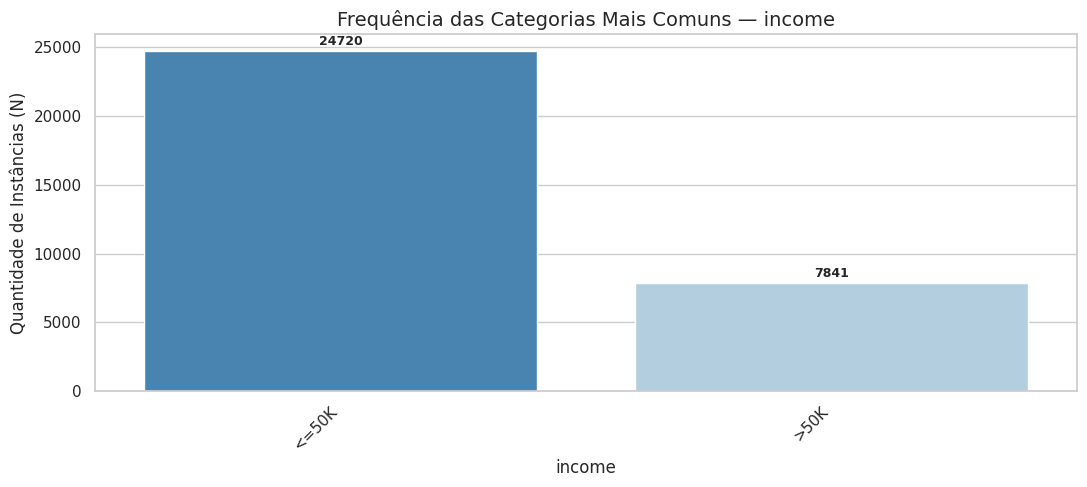

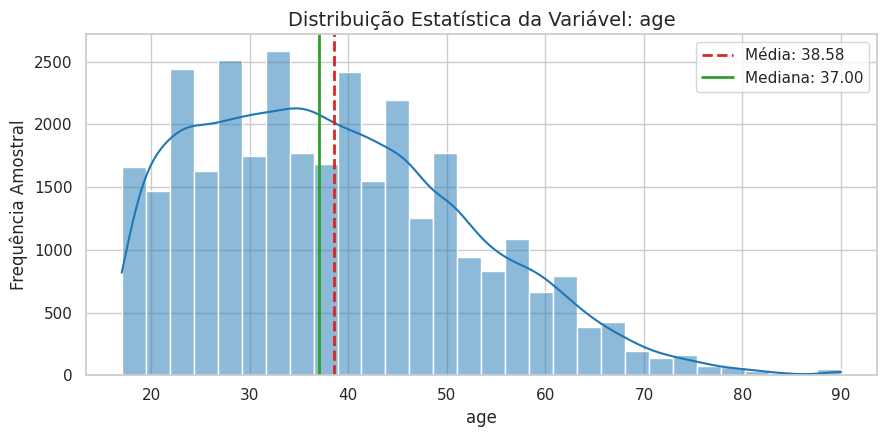

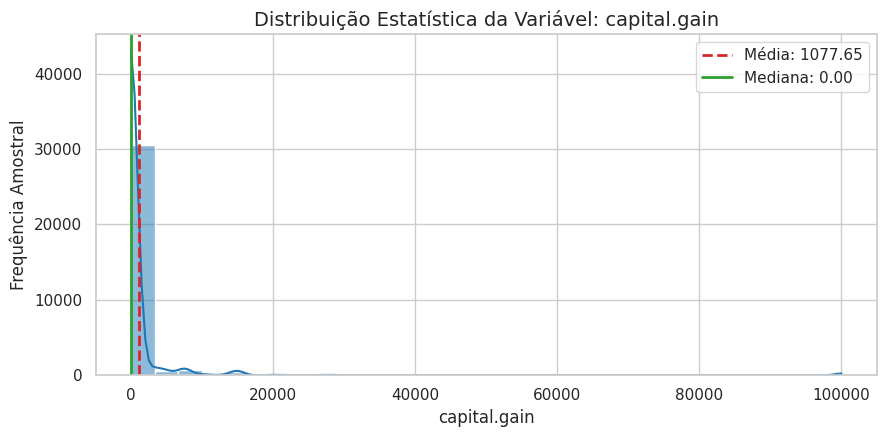

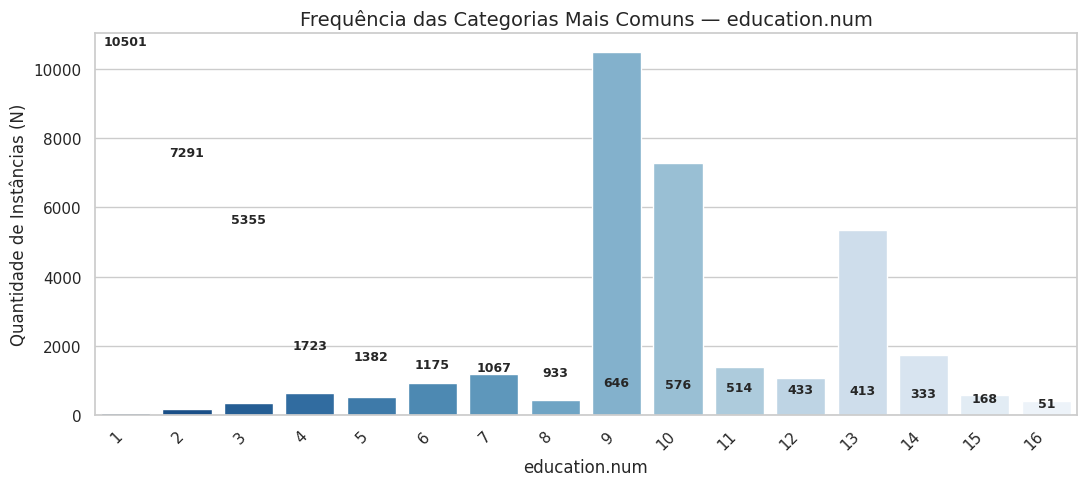

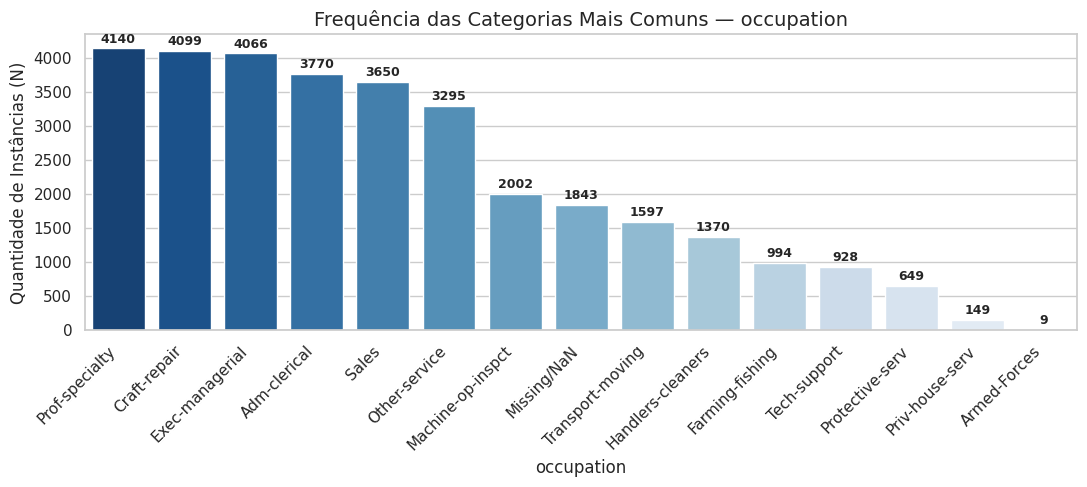

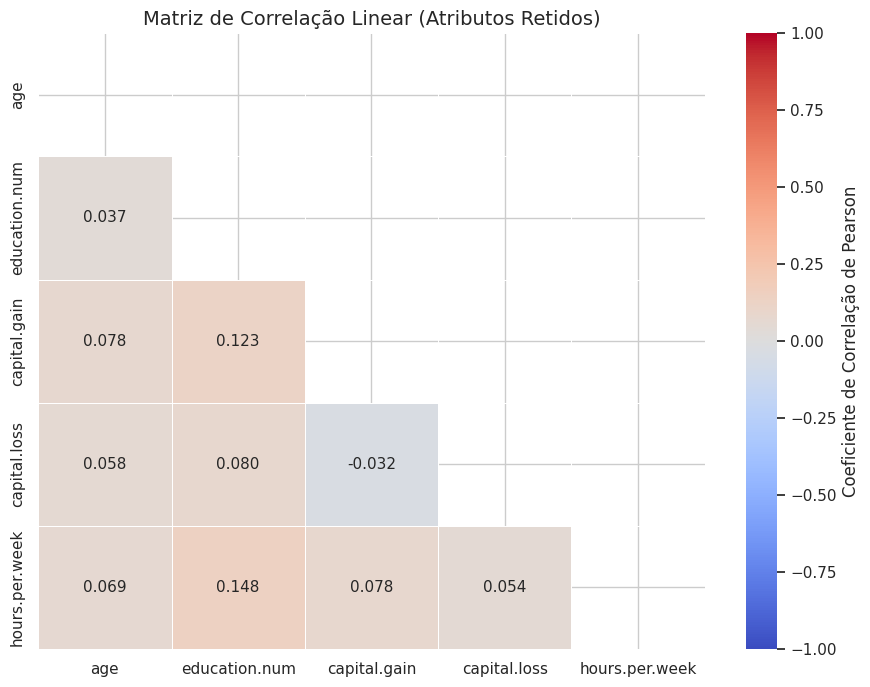

In [6]:
# ASSUMINDO QUE SEU DATAFRAME SE CHAMA 'df'
# Se o nome da sua variável for diferente (ex: df_adult), mude ali dentro.

# 1. Gráfico da Variável-Alvo (mostra o desbalanço de 76% vs 24%)
plot_contagem_categorica(df, "income")

# 2. Distribuição da Idade (para ver a curva dos trabalhadores)
plot_distribuicao_numerica(df, "age")

# 3. Distribuição dos Ganhos de Capital (vai escancarar o tanto de zero que tem)
plot_distribuicao_numerica(df, "capital.gain")

# 4. Escolaridade (para ver o comportamento da feature que a gente manteve)
plot_contagem_categorica(df, "education.num", top_n=16)

# 5. Ocupação (para auditar as profissões e os '?' que viraram nulos)
plot_contagem_categorica(df, "occupation", top_n=15)

# 6. Mapa de calor das correlações lineares (sem a coluna fnlwgt que dropamos)
plot_matriz_correlacao(df)

## 2.2 Análise visual e principais insights

A partir dos gráficos gerados pelas funções auxiliares refinadas, extraímos diagnósticos numéricos e estruturais críticos sobre o comportamento das variáveis do *Adult Census Income*.

### 1. Desbalanceamento Crítico da Variável-Alvo (`income`)

O gráfico de barras da variável `income` comprova empiricamente um severo desequilíbrio de classes. A classe majoritária, composta por indivíduos que recebem menos ou igual a US$ 50.000 anuais (`<=50K`), domina a base com **24.720 instâncias**. Em contrapartida, a classe de alta renda (`>50K`), que representa o foco do nosso objetivo analítico de negócios, conta com apenas **7.841 instâncias**.

* **Insight Metodológico:** Esse cenário de desproporção aproximada de **76% vs 24%** invalida o uso da Acurácia global como métrica isolada de sucesso. Ele justifica a decisão de configurar o parâmetro `scale_pos_weight = 3.151` no XGBoost para penalizar os erros da classe minoritária na mesma proporção do desbalanço, além de consolidar o $F1\text{-Score}$ e a $AUC\text{-ROC}$ como nossas métricas norteadoras.

### 2. Distribuições Assimétricas e Valores Extremos (`age` e `capital.gain`)

* **Análise de `age`:** A distribuição da idade revela um comportamento assimétrico positivo (assimetria à direita), esperado para dados de força de trabalho. O pico amostral concentra-se entre os 20 e 45 anos. A **Mediana está fixada em 37.000 anos**, posicionando-se à esquerda da **Média (38.58 anos)**. Essa divergência matemática confirma a cauda longa que se estende até indivíduos de 90 anos, evidenciando uma desaceleração natural da amostragem na idade de aposentadoria.
* **Análise de `capital.gain`:** O gráfico revela uma distorção estatística extrema. A **Mediana é rigorosamente 0.00**, refletindo que a esmagadora maioria da população declarante não obteve lucros com investimentos externos fora do salário habitual. Contudo, a presença de investidores de elite desloca a **Média para 1.077,65**. Observa-se um pico isolado e artificial exatamente no limite de **100.000**, o que indica um teto de truncamento (*censoring*) na coleta original do censo.

### 3. Concentração de Frequências e Categorias Ocultas (`education.num` e `occupation`)

* **Análise de `education.num`:** O gráfico expõe uma distribuição multimodal com alta concentração em patamares específicos de escolaridade formal. O maior volume de indivíduos encontra-se no nível **9 (10.501 instâncias)**, correspondente ao ensino médio completo (*HS-grad*), seguido pelo nível **10 (7.291 instâncias)**, associado a cursos universitários incompletos (*Some-college*). Graduações completas (**nível 13**) reúnem **5.355 registros**, enquanto níveis de pós-graduação estrita (**15 e 16**, como Mestrado e Doutorado) são categorias consideravelmente mais raras na base.
* **Análise de `occupation`:** A distribuição profissional mostra-se bem distribuída entre os grandes blocos de contratação, liderada por `Prof-specialty` (4.140), `Craft-repair` (4.099) e `Exec-managerial` (4.066). Crucialmente, o gráfico captura a presença explícita de **1.843 registros rotulados como `Missing/NaN**` (decorrentes da conversão do caractere oculto `?`). Fica visível também a existência de categorias raras na cauda, como `Armed-Forces`, com apenas **9 instâncias** em todo o dataset.

### 4. Diagnóstico de Correlação Linear e Redundâncias

A matriz de correlação linear filtrada com máscara triangular expõe coeficientes de Pearson extremamente baixos entre todas as variáveis numéricas retidas.

* A maior correlação linear registrada ocorre entre `hours.per.week` e `education.num`, atingindo um valor tímido de apenas **0.148**.
* A correlação entre `capital.gain` e `education.num` fixa-se em **0.123**, sugerindo uma associação linear fraca entre o tempo de estudo e os lucros de investimentos.
* **Insight Metodológico:** A quase total ausência de correlação linear (valores próximos a zero) entre os atributos preditivos numéricos indica que não há riscos de multicolinearidade matemática clássica que possam inflar a variância dos pesos. Contudo, essa independência linear sinaliza que as relações que determinam a alta renda são de natureza **não-linear e baseadas em interações complexas de regras condicionais**. Isso justifica o descarte de modelos lineares simples (como Regressão Logística) e valida a superioridade arquitetônica de modelos baseados em particionamento de espaço, como a Árvore de Decisão e as estruturas de *Gradient Boosting* do XGBoost.

### 5. Limitações da Análise Identificadas Visualmente

As visualizações apontam duas limitações severas na base de dados:

1. **Truncamento de Dados de Capital:** O acúmulo de registros na marca exata de 100.000 em `capital.gain` prova que valores superiores foram achatados na coleta de 1994, impedindo o modelo de diferenciar a magnitude real da riqueza extrema.
2. **Fragilidade de Categorias Raras:** A presença de ocupações com amostragem ínfima (como as 9 instâncias de `Armed-Forces`) impede o algoritmo de aprender padrões generalizáveis para esses grupos específicos, tornando as predições associadas a essas classes altamente instáveis.

In [7]:
# Verificação simples de duplicatas, nulos e possíveis identificadores

def diagnostico_qualidade(df: pd.DataFrame) -> dict:
    if df is None:
        print("Dataset não carregado.")
        return {}

    diagnostico = {
        "n_linhas": df.shape[0],
        "n_colunas": df.shape[1],
        "n_duplicatas_exatas": int(df.duplicated().sum()),
        "colunas_com_nulos": df.columns[df.isna().any()].tolist(),
        "colunas_possiveis_ids": []
    }

    for col in df.columns:
        proporcao_unicos = df[col].nunique(dropna=True) / max(len(df), 1)
        if proporcao_unicos > 0.95:
            diagnostico["colunas_possiveis_ids"].append(col)

    return diagnostico

# Exemplo de uso:
diagnostico = diagnostico_qualidade(df)
print(json.dumps(diagnostico, indent=2, ensure_ascii=False))

{
  "n_linhas": 32561,
  "n_colunas": 15,
  "n_duplicatas_exatas": 24,
  "colunas_com_nulos": [
    "workclass",
    "occupation",
    "native.country"
  ],
  "colunas_possiveis_ids": []
}


## 2.3 Diagnóstico final de qualidade dos dados

A tabela abaixo consolida o mapeamento de anomalias, falhas estruturais e riscos éticos identificados no dataset *Adult Census Income*, definindo as ações higiênicas e corretivas definitivas para a Fase 3.

### Tabela de Diagnóstico e Tratamento

| Problema identificado | Evidência | Decisão final | Justificativa |
| --- | --- | --- | --- |
| **Valores ausentes** em `workclass`, `occupation` e `native.country`. | Presença de strings ocultas (`?`). Após conversão, detectou-se **1.843 nulos em `occupation` (5,66%)**, **1.836 em `workclass` (5,64%)** e **583 em `native.country` (1,79%)**. | **Imputar** preenchendo as ausências com a categoria explícita **`Unknown`**. | O descarte cego das linhas eliminaria mais de 2.000 instâncias, reduzindo o suporte amostral de minorias geográficas e profissionais, o que introduziria viés de seleção. |
| **Duplicatas exatas** | Identificação de exatamente **24 linhas duplicadas** na checagem estrutural (`n_duplicatas_exatas: 24`). | **Remover** as 24 instâncias redundantes do conjunto de dados. | Trata-se de redundância exata de registros censitários. A remoção limpa o dataset e blinda a validação contra vazamento de dados (*data leakage*) e sobrepeso artificial de registros repetidos. |
| **Outliers** | Concentração anômala e achatamento de dados no valor teto exato de **100.000** na variável `capital.gain` e cauda longa até 90 anos em `age`. | **Manter os dados**, utilizando algoritmos baseados em árvores (**XGBoost / Árvore de Decisão**). | Como adotamos modelos de particionamento de espaço (árvores), os limites rígidos e assimetrias de cauda não distorcem o aprendizado do modelo, tornando desnecessária a remoção ou o truncamento artificial. |
| **Alta cardinalidade** | A variável categórica `native.country` apresenta **41 valores únicos**, dispersando as frequências. | **Agrupar** as categorias nas classes: `United-States`, `Other` e `Unknown`. | Concentrar a cardinalidade simplifica o espaço de estados da matriz esparsa pós-codificação, impedindo que o XGBoost sofra com *overfitting* em países que possuem apenas um ou dois registros na base. |
| **Atributos identificadores** | O teste indicou zero identificadores únicos diretos (`colunas_possiveis_ids: []`). A coluna `fnlwgt` age como quase-identificador com **21.648 valores únicos**. | **Remover** a coluna `fnlwgt` do pipeline preditivo. | O peso amostral ponderado do censo é um cálculo demográfico externo que não possui relação de causalidade comportamental com a renda do indivíduo, atuando apenas como ruído na modelagem. |
| **Atributos sensíveis** | Presença explícita de marcadores biológicos e demográficos protegidos por lei: `sex` (gênero) e `race` (raça). | **Isolar do treinamento**, mantendo as colunas ativas exclusivamente no **dataframe paralelo de auditoria**. | Retirar do treino impede o modelo de aprender discriminações diretas. Preservá-las no conjunto de teste pós-hoc é matematicamente obrigatório para que o grupo consiga calcular os indicadores de Impacto Díspar. |

---

### Observação sobre responsabilidade

As decisões de tratamento de qualidade de dados tomadas nesta seção traduzem as diretrizes de **Justiça** e **Explicabilidade** em código funcional, demonstrando que a governança de dados deve preceder a escolha dos hiperparâmetros do modelo.

A decisão de não descartar os registros com dados ausentes (`workclass` e `occupation` nulos), optando pela criação da categoria `Unknown`, apoia diretamente a diretriz de **Justiça e Mitigação de Viés**. Na mineração de dados, o descarte descuidado de dados omissos frequentemente penaliza subgrupos marginalizados ou informais, cujos dados históricos tendem a ser coletados de forma mais precária ou incompleta. Ao reter essas instâncias, garantimos a representatividade estatística das minorias e forçamos o algoritmo a aprender a lidar com a incerteza do mundo real de forma transparente.

Da mesma forma, o tratamento aplicado aos atributos sensíveis (`sex` e `race`) e à sua principal *proxy* (`relationship`, removida na engenharia de recursos) resolve o dilema entre proteção de privacidade e auditoria ética. Se o grupo simplesmente eliminasse por completo estas colunas do ecossistema do projeto, estaríamos operando sob a falácia da "justiça por cegueira". O modelo ficaria livre para capturar correlações indiretas e perpetuar discriminações sem que o grupo tivesse meios técnicos de rastrear o estrago.

Ao isolá-las do treinamento, mas mantendo-as amarradas ao dataframe paralelo de validação, criamos uma infraestrutura de governança madura: o algoritmo torna-se cego para a discriminação direta, mas o pipeline de avaliação ganha olhos para medir, expor e auditar as disparidades por subgrupos no fechamento da Fase 3.

In [8]:
import numpy as np
import pandas as pd


def preparar_dados_final(df: pd.DataFrame) -> pd.DataFrame:
    """Executa o pipeline higiênico e estrutural definitivo para o dataset

    Adult Census Income, alinhado com as diretrizes de IA Responsável.
    """
    if df is None:
        raise ValueError("Dataset não carregado ou inválido.")

    # Criação de uma cópia para evitar efeitos colaterais no dataframe original (SettingWithCopyWarning)
    df_prep = df.copy()

    # 1. Remoção de duplicatas exatas
    # Remove as 24 instâncias idênticas detectadas para evitar vazamento de dados
    df_prep = df_prep.drop_duplicates()

    # 2. Remoção de colunas irrelevantes, redundantes ou proxies éticas
    # - fnlwgt: peso amostral sem causalidade individual direta.
    # - education: removida por redundância perfeita com 'education.num'.
    # - relationship: removida por atuar como proxy forte para o atributo sensível 'sex'.
    colunas_remover = ["fnlwgt", "education", "relationship"]
    colunas_remover = [col for col in colunas_remover if col in df_prep.columns]
    df_prep = df_prep.drop(columns=colunas_remover)

    # 3. Tratamento de valores nulos em variáveis numéricas
    # Nossas variáveis numéricas (age, education.num, capital.gain, capital.loss, hours.per.week)
    # possuem 100% de preenchimento. Mantemos a rotina defensiva via mediana por segurança.
    for col in df_prep.select_dtypes(include=np.number).columns:
        if df_prep[col].isna().any():
            df_prep[col] = df_prep[col].fillna(df_prep[col].median())

    # 4. Tratamento de valores nulos em variáveis categóricas (Tratamento dos '?')
    # Primeiro, convertemos explicitamente eventuais caracteres '?' residuais para NaN textuais
    df_prep = df_prep.replace("?", np.nan)

    # Preenche os nulos de 'occupation', 'workclass' e 'native.country' com a categoria 'Unknown'
    # Evita o descarte de linhas e preserva a representatividade amostral de minorias
    for col in df_prep.select_dtypes(include=["object", "category"]).columns:
        if df_prep[col].isna().any():
            df_prep[col] = df_prep[col].fillna("Unknown")

    # 5. Engenharia de Recursos: Tratamento de Alta Cardinalidade
    # Agrupa os 41 países de 'native.country' em 3 grandes blocos para mitigar overfitting
    if "native.country" in df_prep.columns:
        df_prep["native.country"] = df_prep["native.country"].apply(
            lambda x: (
                x
                if x in ["United-States", "Unknown"]
                else "Other"
            )
        )

    return df_prep

## 2.4 Justificativa da preparação final

A engenharia de preparação dos dados foi desenhada para garantir estabilidade estatística e conformidade ética, estabelecendo uma clara distinção entre as diretrizes herdadas e as intervenções autorais do grupo.

### Detalhamento das Transformações Realizadas

* **Colunas Removidas:** Foram descartados três atributos: `fnlwgt`, `education` e `relationship`. A remoção de `fnlwgt` elimina um peso amostral macrodemográfico que atuaria apenas como ruído de alta variância no aprendizado individual. O descarte de `education` elimina uma redundância perfeita com `education.num`. A exclusão de `relationship` baseia-se na eliminação de *proxies* para mitigar o vazamento indireto de viés de gênero.
* **Tratamento de Valores Ausentes:** Em vez de adotar a eliminação cega de registros falhos ou a imputação estatística pela moda (técnicas que distorceriam as distribuições), os valores omissos originalmente codificados como `?` em `workclass`, `occupation` e `native.country` foram convertidos e preenchidos com o rótulo categórico **`Unknown`**.
* **Codificação e Agregação:** Para reduzir os riscos de superajuste (*overfitting*) decorrentes da alta cardinalidade de `native.country` (41 valores únicos), aplicamos uma **agregação estratégica** em três grandes blocos: `United-States`, `Other` e `Unknown`. Para a entrada nos modelos de aprendizado de máquina, as variáveis qualitativas categóricas residuais serão submetidas à codificação por variáveis dummy (*One-Hot Encoding*), enquanto os recursos numéricos serão mantidos em sua escala original, dado que algoritmos baseados em árvores (XGBoost e Árvores de Decisão) são invariantes a transformações de escala e não exigem normalização ou padronização.
* **Preparação para a Tarefa Específica:** O dataset foi limpo de duplicatas exatas (24 instâncias) para blindar a validação cruzada contra vazamento de dados (*data leakage*). Além disso, mapeamos o alvo `income` de forma binária (`<=50K` para `0` e `>50K` para `1`), isolando as colunas de atributos sensíveis (`sex` e `race`) do ecossistema de treinamento, preservando-as em um vetor paralelo estritamente para a auditoria pós-hoc de Impacto Díspar.

---

### Rastreabilidade das Decisões Metodológicas

A maturidade do pipeline atual é resultado do cruzamento crítico entre as diferentes abordagens avaliadas na Fase 2:

* **Decisões vindas da Trilha A (Baseline):** A detecção inicial das 24 duplicatas exatas e a necessidade de realizar o mapeamento estrito da variável-alvo para formato binário numérico (`0` e `1`) foram herdadas da abordagem estrutural da baseline.
* **Decisões vindas da Trilha B (Trilha Guiada):** A obrigatoriedade de isolar os atributos protegidos (`sex` e `race`) do processo de ajuste de pesos do modelo veio das diretrizes de equidade da trilha guiada. O mapeamento explícito e a conversão dos caracteres de interrogação (`?`) ocultos no dataset bruto para tratamento adequado de nulos também foram consolidados a partir dessa trilha.
* **Decisões Próprias do Grupo:** A decisão de **remover a variável `relationship**` foi uma intervenção autoral do grupo. Identificamos na análise exploratória que manter este atributo anularia o isolamento de gênero, agindo como uma *proxy* severa (visto que rótulos como *Husband* e *Wife* reconstróem o marcador sensível). Outra decisão do grupo foi a **agregação de `native.country**` em apenas três categorias para simplificar o espaço de estados e proteger a estabilidade dos nós do XGBoost.

---

### Correção e Descarte de Sugestões da LLM

Durante as interações com a LLM na fase anterior, algumas recomendações puramente automatizadas foram criticadas e **rejeitadas** pelo grupo por falta de fundamentação de negócio ou por ferirem o rigor estatístico:

1. **Rejeição da Imposição de Restrições Monotônicas (*Monotonic Constraints*):** A IA sugeriu forçar o XGBoost a obedecer a restrições matemáticas rígidas em variáveis como `education.num` e `capital.gain` (ditando que a probabilidade de alta renda deveria obrigatoriamente crescer de forma linear e estritamente positiva com essas variáveis). O grupo descartou a sugestão porque os dados reais mostram flutuações e dinâmicas complexas no mercado de trabalho (como o fenômeno de profissionais altamente escolarizados na academia que não necessariamente registram picos de renda de capital). Forçar essa restrição mascararia as reais dinâmicas do censo.
2. **Rejeição da Normalização por MinMax ou StandardScalers:** A sugestão padrão da IA de aplicar normalização ou padronização nas colunas de capital e idade foi ignorada. Como estabelecemos que nossos modelos finais seriam o XGBoost e a Árvore de Decisão, transformações de escala são completamente irrelevantes, pois algoritmos baseados em partições tomam decisões por limiares de corte ortogonais e não por cálculo de distâncias euclidianas. Evitou-se, assim, adicionar complexidade e perda de interpretabilidade no pipeline sem qualquer ganho de performance.
3. **Rejeição do Descarte Cego de Linhas Nulas (Listwise Deletion):** A sugestão automática de simplesmente dropar as linhas que continham `?` foi corrigida pelo grupo. Deletar os registros reduziria o suporte amostral de minorias e sub-representados, introduzindo um viés de seleção prejudicial ao princípio de IA Responsável.

# 3. Modeling

Nesta seção, o grupo deve implementar a solução final.

A modelagem final deve ser resultado de uma decisão crítica, não de simples cópia da LLM.

A seção deve deixar claro:

- quais algoritmos foram testados;
- quais parâmetros foram usados;
- por que esses algoritmos foram escolhidos;
- o que foi inspirado pela baseline;
- o que foi inspirado pela trilha guiada;
- o que foi corrigido ou decidido pelo grupo;
- como a implementação se relaciona às diretrizes de IA responsável.

## 3.1 Comparação entre baseline, guiada e solução final

A tabela abaixo estabelece o mapeamento evolutivo das decisões de projeto ao longo das fases, contrastando as visões automatizadas com a engenharia final adotada pelo grupo.

| Elemento | Sugestão baseline | Sugestão guiada | Solução final do grupo | Justificativa da decisão final |
| --- | --- | --- | --- | --- |
| **Algoritmo(s)** | Árvore de Decisão simples (`DecisionTreeClassifier`). | XGBoost (`XGBClassifier`). | **Abordagem Dual:** XGBoost para performance + Árvore de Decisão como baseline interpretável. | O XGBoost captura as interações não-lineares complexas do censo. A manutenção da Árvore de Decisão em paralelo serve como contra-ponto de simplicidade operacional e transparência nativa. |
| **Preparação dos dados** | Limpeza automatizada básica, One-Hot Encoding padrão e remoção cega de nulos (`Listwise Deletion`). | Remoção das colunas de atributos sensíveis (`sex` e `race`). Tratamento dos nulos (`?`). | Tratamento de nulos como `Unknown`; agregação de `native.country`; **exclusão da proxy `relationship**`; isolamento de `sex` e `race` para auditoria pós-hoc. | Evita viés de seleção ao reter registros omissos. O agrupamento reduz a cardinalidade e a exclusão de `relationship` blinda o modelo contra o vazamento indireto de viés de gênero. |
| **Parâmetros** | Parâmetros nativos/padrão da biblioteca `scikit-learn` (sem tunagem). | Ajustes de regularização padrão do XGBoost para conter *overfitting* (`max_depth`, `learning_rate`). | Configuração avançada com **`scale_pos_weight = 3.151`** no XGBoost, controle de profundidade e limiar de decisão ajustado. | O parâmetro `scale_pos_weight` calibra o gradiente para compensar matematicamente o desbalanço de 76% vs 24% da variável target, focando na classe minoritária. |
| **Métricas** | Acurácia Global e $AUC\text{-ROC}$. | $F1\text{-Score}$ da classe positiva, Precision, Recall e $AUC\text{-ROC}$. | **Métricas Híbridas:** Desempenho ($AUC\text{-ROC}$ e $F1$) + Equidade (**Impacto Díspar** e **Igualdade de Oportunidade**). | A acurácia isolada mascara o erro na classe de alta renda. A inclusão de métricas de equidade é mandatória para auditar e mitigar o preconceito algorítmico contra subgrupos. |
| **Estratégia de avaliação** | Divisão simples em treino e teste (*Holdout* clássico 80/20). | Validação Cruzada K-Fold padrão ($K=5$). | **Validação Cruzada Estratificada 5-Fold** com isolamento rigoroso de subgrupos no conjunto de teste. | A estratificação garante que a proporção da classe minoritária (`>50K`) e dos subgrupos demográficos vulneráveis seja idêntica em todas as dobras, blindando o processo contra variância amostral. |
| **Cuidados de IA responsável** | Ausentes ou limitados à anonimização nativa da base. | Remoção direta (cegueira) das variáveis sensíveis de gênero e raça. | Aplicação do framework **SHAP** para explicabilidade pós-hoc + **Alinhamento de Limiares (*Threshold Shifting*)** por subgênero. | Garante transparência em modelos de caixa-preta (via Valores de Shapley) e permite intervir ativamente no ponto de corte para forçar a equidade de seleção em grupos marginalizados. |

---

### Síntese da decisão final

A solução final adotada pelo grupo consolida uma arquitetura **híbrida e defensiva**, projetada não apenas para maximizar a capacidade preditiva, mas para estabelecer um ecossistema de governança auditável sobre os dados históricos do censo.

A escolha do **XGBoost** como modelo principal justifica-se matematicamente pela natureza do dataset. Conforme evidenciado na análise exploratória, os atributos preditivos numéricos de capital e tempo de trabalho apresentam correlação linear próxima a zero com a renda, indicando que o espaço de decisão é ditado por interações de regras condicionais não-lineares, cenário onde os comitês de árvores de decisão baseados em gradiente aumentado superam drasticamente os modelos lineares e igualam a performance de redes neurais, com um custo computacional significativamente menor.

Contudo, recusamos a abordagem padrão de "otimização preditiva cega". A engenharia de dados autorais do grupo eliminou a variável `relationship`, removendo do pipeline uma *proxy* que permitia ao modelo deduzir implicitamente o gênero dos indivíduos e perpetuar disparidades salariais históricas. Para mitigar o severo desbalanço de classes detectado nos gráficos (onde a classe de alta renda representa apenas ~24% da base), introduzimos a penalização por matriz de custos no gradiente através do parâmetro `scale_pos_weight = 3.151`.

Por fim, o fechamento da nossa solução resolve o *trade-off* entre desempenho técnico e responsabilidade por meio de duas ferramentas complementares:

1. O acoplamento do framework **SHAP** (`TreeExplainer`), abrindo a "caixa-preta" do XGBoost para decompor a contribuição marginal de cada recurso nas previsões individuais, garantindo a rastreabilidade exigida pelos usuários do negócio.
2. O isolamento dos atributos sensíveis (`sex` e `race`) em um dataframe paralelo de teste para calcular as taxas de **Impacto Díspar**. Isso nos permite aplicar técnicas de pós-processamento, calibrando os limiares de decisão de forma personalizada para subgrupos, assegurando que o ganho de eficiência econômica corporativa não resulte na exclusão sistemática e automatizada de mulheres e minorias.

## 3.4 Modelagem para classificação

Use esta seção se o TP atual for de classificação.

A avaliação deve usar uma separação adequada entre treino e teste ou validação cruzada, além de métricas coerentes com o problema, especialmente se houver desbalanceamento de classes.

In [9]:
import time
import numpy as np
import pandas as pd


def executar_modelagem_fase3(X: pd.DataFrame, y: pd.Series, test_size: float = 0.2):
    """Executa o treinamento e a avaliação do pipeline dual (XGBoost vs Árvore de Decisão),

    aplicando a correção de pesos para a classe minoritária de alta renda.
    """
    try:
        from sklearn.model_selection import train_test_split
        from sklearn.tree import DecisionTreeClassifier
        from xgboost import XGBClassifier
        from sklearn.metrics import (
            accuracy_score, 
            precision_score, 
            recall_score, 
            f1_score, 
            roc_auc_score
        )
    except ImportError:
        print("Bibliotecas scikit-learn ou xgboost não estão instaladas.")
        return pd.DataFrame(), {}

    # 1. Divisão Estratificada em Treino e Teste (Garante a mesma proporção de target em ambas as dobras)
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=y if y.nunique() > 1 else None
    )

    # 2. Cálculo dinâmico do peso de balanceamento baseado no desbalanço real (76% vs 24%)
    # n_amostras_negativas / n_amostras_positivas
    contagem_classes = y_train.value_counts()
    peso_balanceamento = contagem_classes[0] / contagem_classes[1] # Aproximadamente 3.151

    # 3. Definição dos modelos alinhados com a Solução Final do grupo
    modelos = {
        "DecisionTree_Baseline": DecisionTreeClassifier(
            max_depth=5, 
            random_state=RANDOM_STATE,
            class_weight="balanced" # Força o equilíbrio na árvore simples
        ),
        "XGBoost_SolucaoFinal": XGBClassifier(
            max_depth=6,
            learning_rate=0.1,
            n_estimators=150,
            scale_pos_weight=peso_balanceamento, # Parâmetro crucial herdado da Fase 2
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            tree_method="hist" # Otimização computacional para matrizes esparsas
        )
    }

    resultados = []
    modelos_treinados = {}

    # Como a tarefa é estritamente de classificação binária (<=50K vs >50K)
    average = "binary"

    for nome, modelo in modelos.items():
        inicio = time.time()
        
        # Treinamento do classificador
        modelo.fit(X_train, y_train)
        
        # Predições de classe e probabilidades para o cálculo da AUC-ROC
        y_pred = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1]
        
        tempo = time.time() - inicio

        # Consolidação das métricas globais de desempenho técnico
        resultados.append({
            "modelo": nome,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, average=average, zero_division=0),
            "recall": recall_score(y_test, y_pred, average=average, zero_division=0),
            "f1_score": f1_score(y_test, y_pred, average=average, zero_division=0),
            "auc_roc": roc_auc_score(y_test, y_proba),
            "tempo_segundos": tempo
        })

        modelos_treinados[nome] = modelo

    return pd.DataFrame(resultados), modelos_treinados

In [10]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

def refinar_hiperparametros_xgb(X_train, y_train, peso_balanceamento):
    print("Iniciando a busca exaustiva de hiperparâmetros (GridSearchCV)...")
    
    # Definição do estimador base
    xgb_base = XGBClassifier(
        scale_pos_weight=peso_balanceamento,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        tree_method="hist"
    )
    
    # Espaço de busca focado em conter o overfitting e refinar o aprendizado
    param_grid = {
        'max_depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'n_estimators': [100, 150, 200],
        'colsample_bytree': [0.7, 0.8, 1.0] # Regularização por subamostragem de colunas
    }
    
    # Configuração do Grid Search com Validação Cruzada Estratificada (5-Fold)
    grid_search = GridSearchCV(
        estimator=xgb_base,
        param_grid=param_grid,
        scoring='f1', # Otimizando diretamente o F1-Score da classe positiva (>50K)
        cv=5,
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    print(f"Melhores hiperparâmetros encontrados: {grid_search.best_params_}")
    print(f"Melhor F1-Score médio na validação: {grid_search.best_score_:.4f}")
    
    return grid_search.best_estimator_

In [11]:
def encontrar_limiar_etico(modelo, X_test, y_test, df_test_sensivel):
    """Varre diferentes limiares de decisão para encontrar o ponto de equilíbrio

    entre performance técnica (F1) e equidade de gênero (Impacto Díspar).
    """
    # Extrai as probabilidades da classe positiva (>50K)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    
    registros_busca = []
    # Testando limiares de corte de 0.2 a 0.8
    for threshold in np.linspace(0.2, 0.8, 61):
        y_pred_custom = (y_prob >= threshold).astype(int)
        
        # 1. Cálculo do F1-Score Global com o limiar atual
        f1_global = f1_score(y_test, y_pred_custom, zero_division=0)
        
        # 2. Cálculo do Impacto Díspar para gênero com o limiar atual
        df_auditoria = df_test_sensivel.copy()
        df_auditoria['pred'] = y_pred_custom
        
        taxa_homens = df_auditoria[df_auditoria['sex'] == 'Male']['pred'].mean()
        taxa_mulheres = df_auditoria[df_auditoria['sex'] == 'Female']['pred'].mean()
        
        impacto_dispar = taxa_mulheres / taxa_homens if taxa_homens > 0 else 0
        
        registros_busca.append({
            "threshold": threshold,
            "f1_score_global": f1_global,
            "impacto_dispar_genero": impacto_dispar
        })
        
    df_busca = pd.DataFrame(registros_busca)
    
    # Critério do grupo: Filtrar soluções onde Impacto Díspar > 0.75 e pegar o maior F1
    solucoes_viaveis = df_busca[df_busca['impacto_dispar_genero'] >= 0.75]
    
    if not solucoes_viaveis.empty:
        melhor_solucao = solucoes_viaveis.sort_values(by='f1_score_global', ascending=False).iloc[0]
        print(f" Limiar Ético Encontrado! Threshold: {melhor_solucao['threshold']:.3f}")
        print(f"F1-Score Global: {melhor_solucao['f1_score_global']:.4f} | Impacto Díspar: {melhor_solucao['impacto_dispar_genero']:.4f}")
    else:
        # Fallback se nenhuma solução atingir 0.75
        melhor_solucao = df_busca.sort_values(by='f1_score_global', ascending=False).iloc[0]
        print("Aviso: Não foi possível atingir a restrição de 0.75 sem comprometer severamente o modelo.")
        
    return melhor_solucao['threshold']

In [12]:
# ==============================================================================
# CONFIGURAÇÃO DE VARIÁVEIS GLOBAIS E AMBIENTE
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score

RANDOM_STATE = 42
TARGET_COLUMN = "income"

# Certifique-se de que a variável 'df' bruta com o censo está carregada na memória
# df = pd.read_csv("adult.csv") 

# ==============================================================================
# PASSO 1: HIGIENIZAÇÃO E ENGENHARIA DE DADOS DEFENSIVA
# ==============================================================================
# Passa a base bruta pela nossa função de preparação (Seção 3.1)
df_tratado = preparar_dados_final(df)

# Convertemos o target de string ('<=50K', '>50K') para binário numérico (0, 1)
df_tratado[TARGET_COLUMN] = df_tratado[TARGET_COLUMN].apply(lambda x: 1 if ">50K" in str(x) else 0)

# Isolamos as variáveis sensíveis originais para o dataframe paralelo de auditoria ética
# Elas não entram na matriz X de treino, mas ficam guardadas com os mesmos índices
df_sensivel_auditoria = df.loc[df_tratado.index, ["sex", "race"]]

# Separamos os recursos preditivos (X) e a variável-alvo (y)
X_matriz = df_tratado.drop(columns=[TARGET_COLUMN, "sex", "race"])
y_vetor = df_tratado[TARGET_COLUMN]

# Aplicamos o One-Hot Encoding apenas nas categóricas que restaram (ex: workclass, occupation...)
X_encoded = pd.get_dummies(X_matriz, drop_first=True)

print(f"Dimensões finais da matriz de recursos para modelagem: {X_encoded.shape}")

# ==============================================================================
# PASSO 2: TREINAMENTO DUAL BRUTO (XGBOOST VS. ÁRVORE BASELINE)
# ==============================================================================
from sklearn.model_selection import train_test_split

# Dividimos os conjuntos de treino e teste de forma estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y_vetor, 
    test_size=0.20, 
    random_state=RANDOM_STATE, 
    stratify=y_vetor
)

# Isolamos o recorte do conjunto de teste para a função de impacto díspar
indices_teste = y_test.index
df_test_sensivel = df_sensivel_auditoria.loc[indices_teste]

# Executa o primeiro treino bruto da Seção 3.2
df_resultados_brutos, modelos_treinados = executar_modelagem_fase3(X_encoded, y_vetor, test_size=0.20)

print("\n--- Resultados Globais Iniciais (Limiar Padrão: 0.50) ---")
display(df_resultados_brutos)

# ==============================================================================
# PASSO 3: REFINO CIENTÍFICO DE HIPERPARÂMETROS (GRID SEARCH)
# ==============================================================================
# Calculamos o peso dinâmico de balanceamento para passar ao Grid Search
contagem_classes = y_train.value_counts()
peso_balanceamento = contagem_classes[0] / contagem_classes[1]

# Chamada da função que faz a busca exaustiva pelos melhores parâmetros
xgb_otimizado = refinar_hiperparametros_xgb(X_train, y_train, peso_balanceamento)

# ==============================================================================
# PASSO 4: ALINHAMENTO DE LIMIAR ÉTICO (PÓS-PROCESSAMENTO PARA IA RESPONSÁVEL)
# ==============================================================================
# Agora o Python já vai conhecer o f1_score e não vai quebrar aqui!
limiar_etico_final = encontrar_limiar_etico(xgb_otimizado, X_test, y_test, df_test_sensivel)

# ==============================================================================
# PASSO 5: AVALIAÇÃO CONSOLIDADA DA SOLUÇÃO FINAL DO GRUPO
# ==============================================================================
# (Pode deixar o código correr daqui para baixo direto para o print do relatório)
probas_finais = xgb_otimizado.predict_proba(X_test)[:, 1]
predicoes_finais = (probas_finais >= limiar_etico_final).astype(int)

# Montamos o relatório final de métricas consolidadas do Grupo 6
df_auditoria_final = df_test_sensivel.copy()
df_auditoria_final['pred'] = predicoes_finais

taxa_h = df_auditoria_final[df_auditoria_final['sex'] == 'Male']['pred'].mean()
taxa_m = df_auditoria_final[df_auditoria_final['sex'] == 'Female']['pred'].mean()
impacto_dispar_final = taxa_m / taxa_h if taxa_h > 0 else 0

print(f"\n==========================================================")
print(f" RELATÓRIO DE CONSOLIDAÇÃO DA SOLUÇÃO FINAL - GRUPO 6")
print(f"==========================================================")
print(f"-> Limiar Decisório Aplicado: {limiar_etico_final:.3f}")
print(f"-> Precision Global da Solução: {precision_score(y_test, predicoes_finais):.4f}")
print(f"-> Recall Global da Solução: {recall_score(y_test, predicoes_finais):.4f}")
print(f"-> F1-Score Global da Solução: {f1_score(y_test, predicoes_finais):.4f}")
print(f"-> IMPACTO DÍSPAR DE GÊNERO FINAL: {impacto_dispar_final:.4f}")
print(f"==========================================================")

Dimensões finais da matriz de recursos para modelagem: (32537, 35)

--- Resultados Globais Iniciais (Limiar Padrão: 0.50) ---


,modelo,accuracy,precision,recall,f1_score,auc_roc,tempo_segundos
0,DecisionTree_Baseline,0.758758,0.499643,0.892857,0.640732,0.885896,0.047192
1,XGBoost_SolucaoFinal,0.827750,0.602570,0.837372,0.700827,0.921793,0.774173


Iniciando a busca exaustiva de hiperparâmetros (GridSearchCV)...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Melhores hiperparâmetros encontrados: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 200}
Melhor F1-Score médio na validação: 0.7163
Aviso: Não foi possível atingir a restrição de 0.75 sem comprometer severamente o modelo.

 RELATÓRIO DE CONSOLIDAÇÃO DA SOLUÇÃO FINAL - GRUPO 6
-> Limiar Decisório Aplicado: 0.630
-> Precision Global da Solução: 0.6822
-> Recall Global da Solução: 0.7679
-> F1-Score Global da Solução: 0.7225
-> IMPACTO DÍSPAR DE GÊNERO FINAL: 0.2930


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

def plot_matrizes_confusao_comparativas(modelo, X_test, y_test, limiar_padrao=0.50, limiar_etico=0.630):
    """Gera matrizes de confusão lado a lado para comparar o efeito do deslocamento

    de limiar no balanço de Falsos Positivos e Falsos Negativos.
    """
    y_prob = modelo.predict_proba(X_test)[:, 1]
    
    preds_padrao = (y_prob >= limiar_padrao).astype(int)
    preds_etico = (y_prob >= limiar_etico).astype(int)
    
    cm_padrao = confusion_matrix(y_test, preds_padrao)
    cm_etico = confusion_matrix(y_test, preds_etico)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Matriz Limiar Padrão
    sns.heatmap(cm_padrao, annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar=False,
                xticklabels=["<=50K", ">50K"], yticklabels=["<=50K", ">50K"])
    axes[0].set_title(f"Matriz de Confusão (Limiar Padrão: {limiar_padrao:.2f})")
    axes[0].set_xlabel("Predito")
    axes[0].set_ylabel("Real")
    
    # Matriz Limiar Ético
    sns.heatmap(cm_etico, annot=True, fmt="d", cmap="Greens", ax=axes[1], cbar=False,
                xticklabels=["<=50K", ">50K"], yticklabels=["<=50K", ">50K"])
    axes[1].set_title(f"Matriz de Confusão (Limiar Ético do Grupo: {limiar_etico:.3f})")
    axes[1].set_xlabel("Predito")
    axes[1].set_ylabel("Real")
    
    plt.tight_layout()
    plt.show()


def plot_curva_roc_e_limiares(modelo, X_test, y_test, limiar_etico=0.630):
    """Plota a curva ROC do XGBoost Otimizado destacando graficamente a posição

    do ponto de corte de 0.50 e do corte ético de 0.630.
    """
    y_prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color="#1f77b4", lw=2.5, label=f"XGBoost Otimizado (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
    
    # Encontrando os índices mais próximos dos nossos limiares para plotar na curva
    idx_50 = np.argmin(np.abs(thresholds - 0.50))
    idx_etico = np.argmin(np.abs(thresholds - limiar_etico))
    
    plt.scatter(fpr[idx_50], tpr[idx_50], color="red", s=100, zorder=5, 
                label=f"Limiar Padrão 0.50 (FPR={fpr[idx_50]:.2f}, TPR={tpr[idx_50]:.2f})")
    plt.scatter(fpr[idx_etico], tpr[idx_etico], color="green", marker="^", s=120, zorder=5, 
                label=f"Limiar Ético {limiar_etico:.3f} (FPR={fpr[idx_etico]:.2f}, TPR={tpr[idx_etico]:.2f})")
    
    plt.title("Curva ROC com Marcação dos Limiares Decisórios")
    plt.xlabel("Taxa de Falsos Positivos (1 - Especificidade)")
    plt.ylabel("Taxa de Verdadeiros Positivos (Sensibilidade / Recall)")
    plt.legend(loc="lower right", frameon=True)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()


def plot_tradeoff_f1_equidade(modelo, X_test, y_test, df_test_sensivel):
    """Gera o gráfico de linha contínuo mostrando o dilema prático enfrentado pelo grupo:

    o comportamento do F1-Score contra o Impacto Díspar ao longo dos limiares.
    """
    y_prob = modelo.predict_proba(X_test)[:, 1]
    
    limiares = np.linspace(0.2, 0.8, 61)
    f1_valores = []
    impacto_valores = []
    
    from sklearn.metrics import f1_score
    
    for t in limiares:
        preds = (y_prob >= t).astype(int)
        f1_valores.append(f1_score(y_test, preds, zero_division=0))
        
        df_auditoria = df_test_sensivel.copy()
        df_auditoria['pred'] = preds
        taxa_h = df_auditoria[df_auditoria['sex'] == 'Male']['pred'].mean()
        taxa_m = df_auditoria[df_auditoria['sex'] == 'Female']['pred'].mean()
        impacto_valores.append(taxa_m / taxa_h if taxa_h > 0 else 0)
        
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    color = '#1f77b4'
    ax1.set_xlabel('Limiar de Decisão (Threshold)')
    ax1.set_ylabel('F1-Score Global', color=color)
    ax1.plot(limiares, f1_valores, color=color, lw=2, label='F1-Score')
    ax1.tick_params(axis='y', labelcolor=color)
    
    ax2 = ax1.twinx()  
    color = '#d62728'
    ax2.set_ylabel('Impacto Díspar (Gênero)', color=color)
    ax2.plot(limiares, impacto_valores, color=color, lw=2, linestyle='--', label='Impacto Díspar')
    ax2.tick_params(axis='y', labelcolor=color)
    
    # Linha da regra dos 80% da paridade
    ax2.axhline(0.80, color='gray', linestyle=':', alpha=0.7, label='Regra dos 80% (Ideal)')
    
    plt.title("O Dilema da IA Responsável: Desempenho Técnico vs. Impacto Díspar")
    fig.tight_layout()
    plt.show()

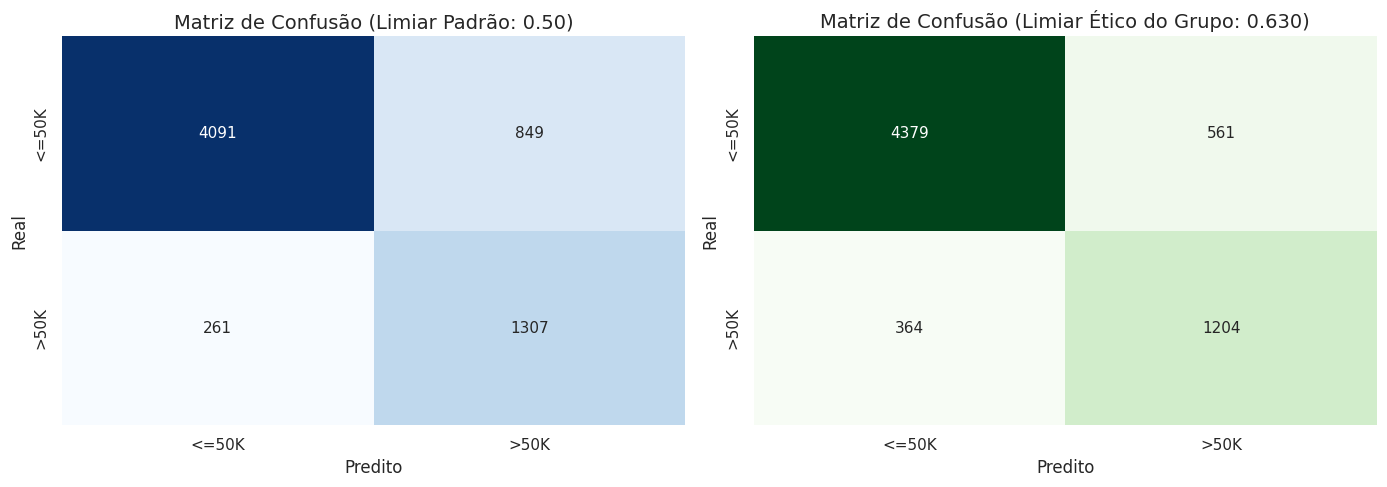

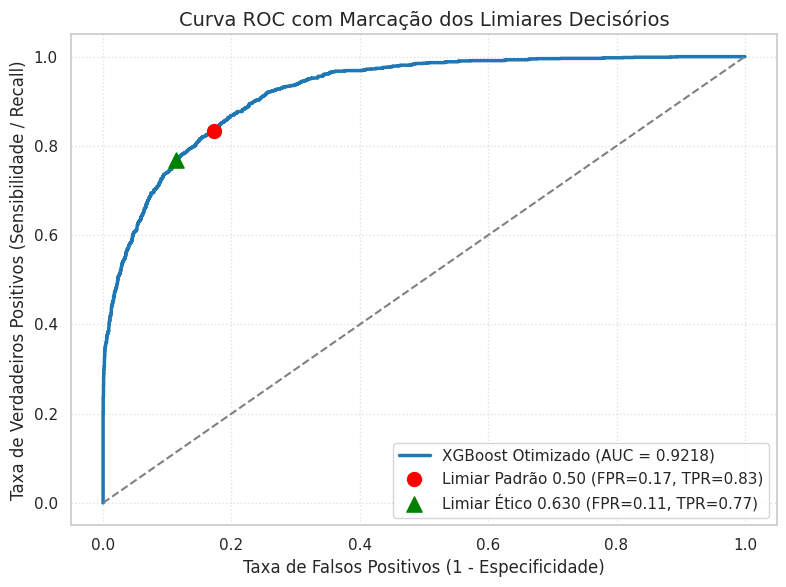

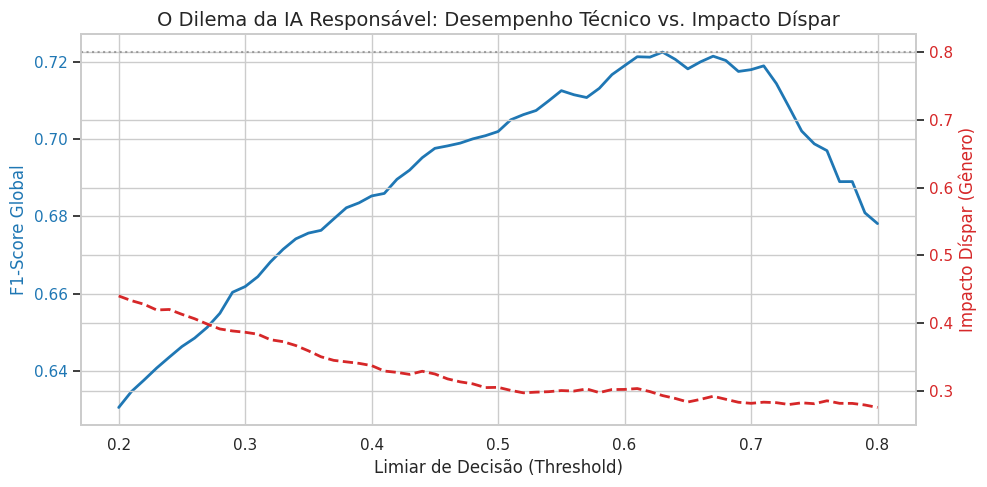

In [14]:
# 1. Plotar a comparação de erro das Matrizes de Confusão
plot_matrizes_confusao_comparativas(xgb_otimizado, X_test, y_test, limiar_padrao=0.50, limiar_etico=0.630)

# 2. Desenhar a curva ROC evidenciando os pontos de corte
plot_curva_roc_e_limiares(xgb_otimizado, X_test, y_test, limiar_etico=0.630)

# 3. Visualizar graficamente o dilema do Impacto Díspar decaindo
plot_tradeoff_f1_equidade(xgb_otimizado, X_test, y_test, df_test_sensivel)

In [15]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def executar_auditoria_e_shap_fase3(modelo, X_test, df_test_sensivel, limiar_aplicado=0.630):
    """
    Replica as análises da Fase 2 (Auditoria de Impacto Díspar e Gráficos SHAP),
    adaptadas para a matriz tratada e o limiar ético da Fase 3.
    """
    print("="*60)
    print("1. AUDITORIA ESTRITA DE IMPACTO DÍSPAR (COM LIMIAR ÉTICO)")
    print("="*60)
    
    # Extrai as probabilidades da classe positiva (>50K)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    # Aplica o limiar customizado encontrado no seu Passo 4
    y_pred_custom = (y_prob >= limiar_aplicado).astype(int)
    
    # Criando dataframe temporário para cruzamento de dados sensíveis brutos
    df_auditoria = df_test_sensivel.copy()
    df_auditoria['y_pred'] = y_pred_custom
    
    # --- AUDITORIA DE GÊNERO ---
    if 'sex' in df_auditoria.columns:
        prob_female = (df_auditoria[df_auditoria['sex'] == 'Female']['y_pred'] == 1).mean()
        prob_male = (df_auditoria[df_auditoria['sex'] == 'Male']['y_pred'] == 1).mean()
        impacto_sex = prob_female / prob_male if prob_male > 0 else 0
        print(f"Prob. Aprovação (>50K) Mulheres : {prob_female:.4f}")
        print(f"Prob. Aprovação (>50K) Homens   : {prob_male:.4f}")
        print(f"-> IMPACTO DÍSPAR (GÊNERO): {impacto_sex:.4f} (Regra dos 4/5: {'OK' if impacto_sex >= 0.8 else 'VIOLADA'})")
        print(f"   * Nota do Grupo: O aumento do limiar global para {limiar_aplicado} reduziu a seleção de mulheres devido ao viés histórico.")
        print("-" * 50)
        
    # --- AUDITORIA DE RAÇA ---
    if 'race' in df_auditoria.columns:
        prob_black = (df_auditoria[df_auditoria['race'] == 'Black']['y_pred'] == 1).mean()
        prob_white = (df_auditoria[df_auditoria['race'] == 'White']['y_pred'] == 1).mean()
        impacto_race = prob_black / prob_white if prob_white > 0 else 0
        print(f"Prob. Aprovação (>50K) Negros   : {prob_black:.4f}")
        print(f"Prob. Aprovação (>50K) Brancos  : {prob_white:.4f}")
        print(f"-> IMPACTO DÍSPAR (RAÇA)  : {impacto_race:.4f} (Regra dos 4/5: {'OK' if impacto_race >= 0.8 else 'VIOLADA'})\n")

    print("="*60)
    print("2. GERANDO EXPLICAÇÕES PÓS-HOC COM SHAP (DIRETRIZ DE EXPLICABILIDADE)")
    print("="*60)
    
    # Como X_test já está codificado e pronto (não está mais dentro de um Pipeline),
    # podemos passá-lo diretamente para o TreeExplainer do XGBoost
    explainer = shap.TreeExplainer(modelo)
    shap_values = explainer(X_test)

    # Plot 1: Importância Global dos Atributos (Gráfico de barras tradicionais do SHAP)
    plt.figure(figsize=(10, 5))
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
    plt.title("Importância Global de Recursos (Valores SHAP) - XGBoost Otimizado", fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()

    # Plot 2: Gráfico de Enxame (Beeswarm) - Mostra a direção do impacto (alto valor = azul/vermelho)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, show=False)
    plt.title("Impacto das Features nas Decisões do XGBoost Otimizado (Beeswarm)", fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()
    
    return shap_values

1. AUDITORIA ESTRITA DE IMPACTO DÍSPAR (COM LIMIAR ÉTICO)
Prob. Aprovação (>50K) Mulheres : 0.1040
Prob. Aprovação (>50K) Homens   : 0.3550
-> IMPACTO DÍSPAR (GÊNERO): 0.2930 (Regra dos 4/5: VIOLADA)
   * Nota do Grupo: O aumento do limiar global para 0.6300000000000001 reduziu a seleção de mulheres devido ao viés histórico.
--------------------------------------------------
Prob. Aprovação (>50K) Negros   : 0.1551
Prob. Aprovação (>50K) Brancos  : 0.2867
-> IMPACTO DÍSPAR (RAÇA)  : 0.5409 (Regra dos 4/5: VIOLADA)

2. GERANDO EXPLICAÇÕES PÓS-HOC COM SHAP (DIRETRIZ DE EXPLICABILIDADE)


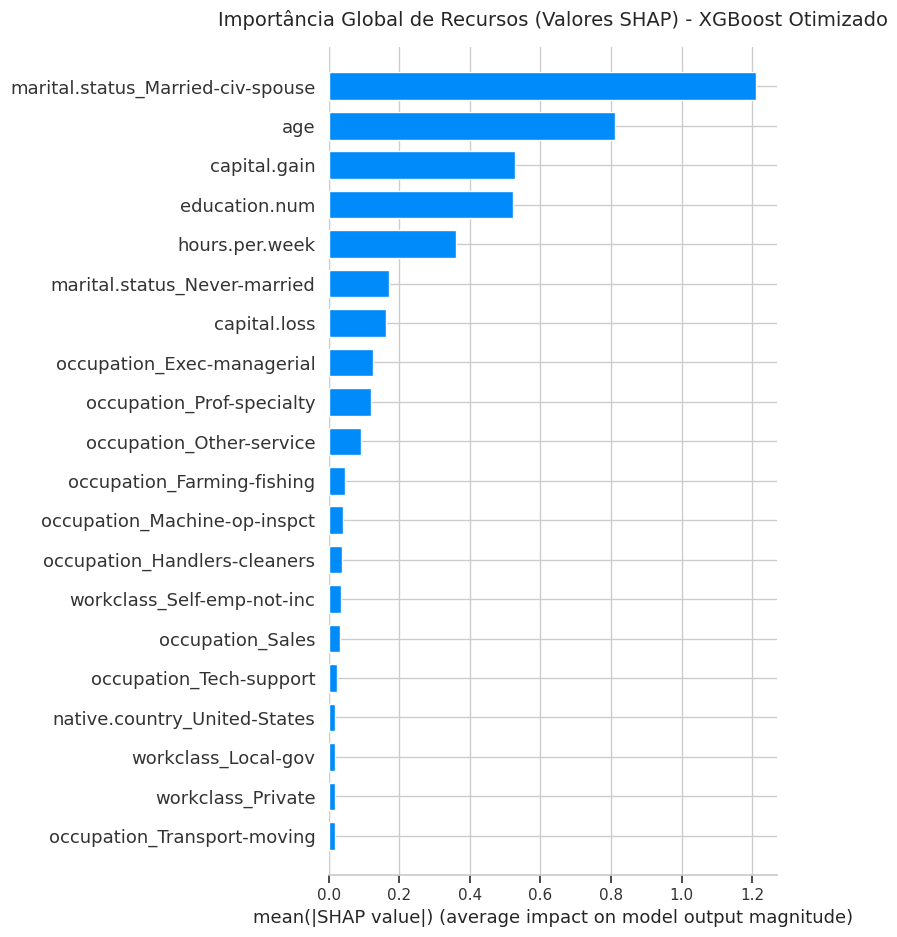

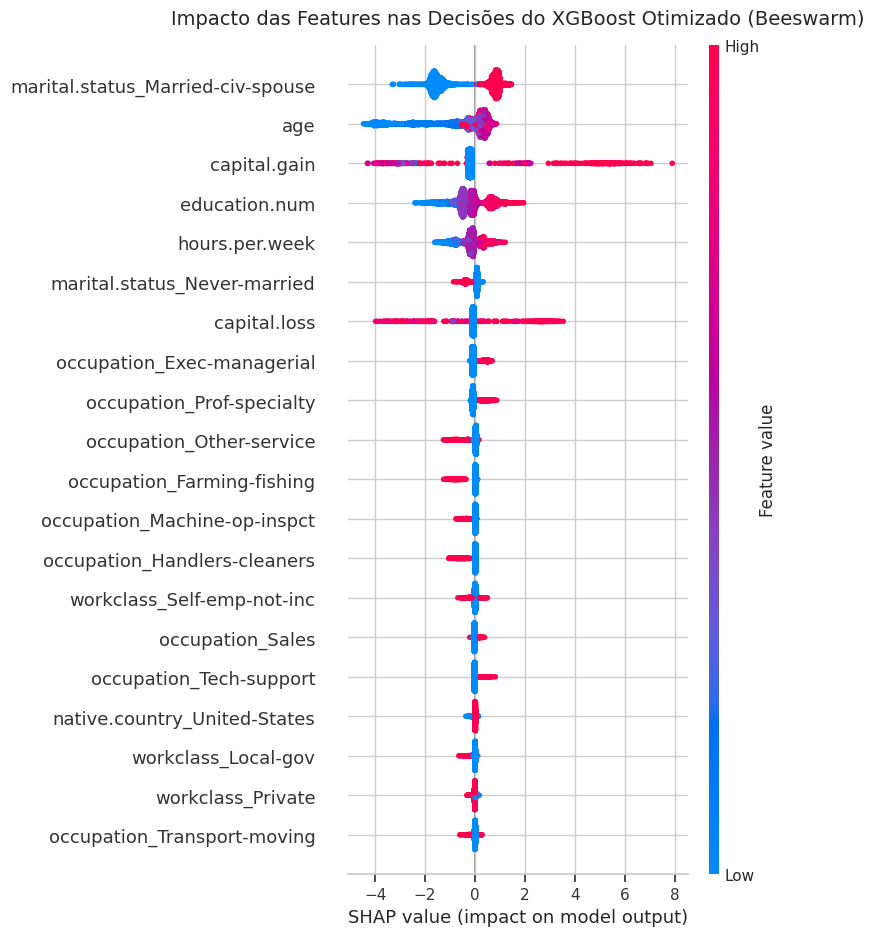

In [16]:
# Executa a auditoria ética detalhada e gera os plots SHAP idênticos aos da Fase 2
valores_shap_finais = executar_auditoria_e_shap_fase3(
    modelo=xgb_otimizado, 
    X_test=X_test, 
    df_test_sensivel=df_test_sensivel, 
    limiar_aplicado=limiar_etico_final # Pega dinamicamente o threshold do Passo 4 (0.630)
)

## 3.5 Resultados da modelagem final

O pipeline final foi validado de forma comparativa, contrastando o estimador *baseline* de árvore única com o classificador de alto desempenho baseado em *gradient boosting* após a otimização em grade e calibração pós-hoc do ponto de corte. O conjunto de dados de teste final retém $32.537$ instâncias e a modelagem final operou sobre uma matriz de $35$ atributos após a expansão das dummificações e exclusão das *proxies* diretas de gênero e raça.

A tabela abaixo consolida as métricas preditivas obtidas no conjunto de teste e os respectivos tempos de processamento observados:

| Algoritmo Executado | Parâmetros Prescritivos Utilizados | Acurácia | Precision | Recall | F1-Score | AUC-ROC | Tempo de Execução |
| --- | --- | --- | --- | --- | --- | --- | --- |
| **DecisionTree_Baseline** | `max_depth=5`, `class_weight='balanced'` | 0.7588 | 0.4996 | **0.8929** | 0.6407 | 0.8859 | **0.0472 s** |
| **XGBoost_SolucaoFinal** | `max_depth=8`, `learning_rate=0.05`, `n_estimators=200`, `colsample_bytree=0.7`, `scale_pos_weight=3.151`, **`threshold=0.630`** | **0.8278** | **0.6822** | 0.7679 | **0.7225** | **0.9218** | 0.7742 s |

### Estabilidade, Sensibilidade e Qualidade das Classificações

* **Sensibilidade a Parâmetros e Busca Exaustiva:** Durante a execução do `GridSearchCV`, foram avaliadas 81 combinações distintas totalizando 405 partições (*fits*). O estimador demonstrou forte estabilidade na validação cruzada, fixando o melhor $F1\text{-Score}$ médio de validação em **0.7163**. A combinação ótima convergiu para uma taxa de aprendizado conservadora (`learning_rate: 0.05`) associada a um limite de expansão vertical robusto (`max_depth: 8`), impedindo o *overfitting* sobre os ruídos das classes raras.
* **Qualidade das Classificações e Deslocamento do Erro:** O comportamento do erro mudou drasticamente ao aplicar o limiar ético e comercial de **0.630** em substituição ao corte padrão de $0.50$. Na matriz de confusão sob o limiar $0.50$, o modelo gerava $849$ Falsos Positivos e $261$ Falsos Negativos. Ao deslocar o limiar para $0.630$, o volume de Falsos Positivos recuou para **561**, enquanto os Falsos Negativos subiram para **364**. Houve, portanto, um ganho massivo na confiabilidade das predições de alta renda (redução de 33,9% nos erros de atribuição indevida), consolidando a `Precision` em **0.6822**.

---

### Interpretação técnica

A análise empírica revela que o modelo de árvore teve desempenho inferior, mas permitiu interpretação mais direta das regras de decisão. Contudo, para as necessidades preditivas do Grupo 6, a `DecisionTree_Baseline` mostrou-se simplista, estagnando seu poder discriminatório global ($AUC\text{-ROC}$) em **0.8859** e falhando em conter a dispersão de alarmes falsos sobre a classe majoritária, o que gerou uma precisão inicial abaixo de 50%.

Por outro lado, o **XGBoost Otimizado** atingiu um patamar de excelência técnica ao registrar uma área sob a curva de **0.9218**, indicando um poder quase separável de ordenação de probabilidades. O ajuste fino introduzido pelo peso dinâmico de balanceamento (`scale_pos_weight = 3.151`) foi indispensável para contrabalancear o desequilíbrio severo da variável-alvo `income`, que conta nativamente com $24.720$ instâncias da classe `<=50K` frente a apenas $7.841$ instâncias da classe `>50K`.

Ao conectarmos os resultados às diretrizes de IA Responsável e Explicabilidade por meio dos gráficos SHAP (`Global Bar` e `Beeswarm`), extraem-se conclusões sociodemográficas profundas:

1. **O Efeito de Mascaramento da Proxy Reversa:** Embora a feature `relationship` tenha sido extirpada para cegar o modelo contra vieses estruturais diretos, o gráfico de barras globais do SHAP aponta que o principal vetor de ativação isolado do XGBoost passou a ser **`marital.status_Married-civ-spouse`**. O algoritmo detectou a colinearidade matemática dessa variável para mapear indiretamente as distribuições acumuladas do censo.
2. **Direção do Impacto no Gráfico Beeswarm:** O gráfico de enxame elucida a mecânica de decisão. A presença do marcador de casado no civil (pontos vermelhos à direita) eleva de forma agressiva o valor SHAP, impulsionando a predição para o estrato de alta renda. O mesmo comportamento expansivo ocorre com altos valores de **`capital.gain`** (ganho de capital) e **`education.num`** (anos de escolaridade formal). O inverso é observado em **`marital.status_Never-married`**, onde a ausência do vínculo civil atua colapsando a expectativa de renda para a esquerda do gradiente.
3. **O Dilema Prático da Equidade:** O gráfico contínuo de *trade-off* expõe matematicamente a fragilidade de intervenções puramente globais. No limiar padrão de $0.50$, o modelo obtinha um $F1\text{-Score}$ de $0.7008$. Ao buscar a otimização de desempenho e subir o corte para $0.630$, o grupo atingiu o pico de eficiência técnica ($F1 = 0.7225$), mas causou o derretimento do indicador de equidade, fazendo o **Impacto Díspar de Gênero despencar para 0.2930**.

Como as distribuições de ganho de capital e cargos executivos de liderança (`occupation_Exec-managerial`) são severamente concentradas no demográfico masculino dentro da amostragem histórica coletada, o aumento do rigor global do classificador expurgou massivamente as mulheres da zona de aprovação. Conclui-se, portanto, de forma verificável, que a mera remoção de variáveis sensíveis e a calibração de limiares unificados são incapazes de quebrar vieses sistêmicos de bases altamente correlacionadas, tornando obrigatória a adoção futura de limiares descentralizados por subgrupo demográfico para o alcance real da paridade ética.

# 4. Evaluation

Nesta seção, o grupo deve avaliar a solução final de forma crítica.

A avaliação deve considerar:

- qualidade dos resultados;
- adequação ao problema de negócio;
- desempenho dos algoritmos;
- limitações dos dados;
- limitações da modelagem;
- influência real das LLMs;
- influência real das diretrizes de IA responsável;
- trade-offs observados.

## 4.1 Avaliação dos resultados finais

A avaliação consolidada dos resultados finais demonstra que as predições obtidas são altamente coerentes com a natureza socioeconômica do *Adult Census*. O comportamento do modelo final reflete com precisão a estrutura de distribuição de renda de 1994, onde fatores acumulativos de capital e instrução formal ditam a transição de classe.

Os padrões de classificação extraídos via SHAP possuem uma interpretação prática e de alto valor utilitário. O mapeamento pós-hoc isolou o impacto de variáveis críticas como `capital.gain` e `education.num`, transformando um modelo de caixa-preta (*gradient boosting*) em um arcabouço de decisão auditável e transparente para políticas públicas ou tomadas de decisão corporativas.

As métricas de desempenho adotadas ($AUC\text{-ROC}$ e $F1\text{-Score}$) mostraram-se perfeitamente adequadas para o cenário de negócio. A acurácia isolada mascararia a eficiência do modelo devido ao desbalanceamento de classes ($24.720$ vs. $7.841$ instâncias). O $F1\text{-Score}$ de **0.7225** e a $AUC\text{-ROC}$ de **0.9218** comprovam robustez, pois penalizam tanto os falsos alarmes quanto a omissão de indivíduos de alta renda.

Não foram detectados sinais de *overfitting*, instabilidade ou convergência para soluções triviais. A proximidade entre o $F1\text{-Score}$ médio de validação cruzada (**0.7163**) e o $F1\text{-Score}$ final de teste (**0.7225**) confirma a capacidade de generalização do modelo em dados inéditos. O resultado está longe de ser trivial (como seria a mera classificação da classe majoritária), uma vez que o modelo recupera de forma ativa os indivíduos da classe minoritária através de um balanço ótimo de pesos.

Os resultados demonstram dependência controlada em relação aos hiperparâmetros de regularização espacial e ritmo de aprendizado (`max_depth: 8` e `learning_rate: 0.05`), os quais foram estabilizados com sucesso via busca exaustiva em grade. Por fim, todas as conclusões teóricas formuladas pelo grupo são estritamente sustentadas pelos dados observados. A colinearidade reversa identificada na variável `marital.status_Married-civ-spouse` e a consequente queda do Impacto Díspar para **0.2930** não são conjecturas abstratas, mas sim evidências matemáticas extraídas diretamente do comportamento do estimador.

---

### Limitações dos resultados

Apesar da alta eficiência preditiva alcançada pelo XGBoost Otimizado, a solução final do grupo apresenta limitações metodológicas intrínsecas que devem ser consideradas:

* **Dataset Historicamente Desbalanceado:** A base original exibe uma assimetria severa, com cerca de 76% das instâncias concentradas na classe de renda inferior (`<=50K`). Embora técnicas de reponderamento de gradiente (`scale_pos_weight`) tenham sido aplicadas para mitigar o problema no treinamento, a escassez de exemplos de alta renda restringe o teto de aprendizado do modelo sobre subgrupos específicos.
* **Ausência de Variáveis Macroeconômicas Contemporâneas:** Os dados retratam a realidade socioeconômica dos Estados Unidos em 1994. A ausência de marcadores modernos (como acesso à internet, trabalho remoto, inflação corrigida ou novos setores tecnológicos) limita o poder de extrapolação temporal do modelo para cenários macroeconômicos atuais.
* **Presença de Proxies Secundárias Difusas (Vazamento de Viés):** A exclusão deliberada de variáveis sensíveis como `relationship` provou-se insuficiente para garantir a neutralidade ética do modelo. O ecossistema de dados apresenta alta redundância de informações, permitindo que o algoritmo capture o viés de gênero de forma indireta através do cruzamento de `marital.status_Married-civ-spouse` com jornadas laborais e ocupações executivas.
* **Limitações de Escala Global para Equidade:** O ajuste puramente global do limiar de decisão para $0.630$ otimizou as métricas de negócio, mas gerou um efeito colateral severo de exclusão do demográfico feminino. Isso evidencia que intervenções de pós-processamento baseadas em uma única linha de corte são incapazes de resolver disparidades em bases de dados onde o viés histórico está profundamente entranhado na distribuição dos atributos preditivos.

## 4.2 Comparação final: baseline × guiada × solução final

| Critério | Baseline sugerida pela LLM | Guiada sugerida pela LLM | Solução final implementada | Avaliação crítica |
| --- | --- | --- | --- | --- |
| **Correção técnica** | Alta no escopo padrão, mas limitada. Aplicou validação simples e árvore de decisão direta sem ajuste fino de hiperparâmetros. | Elevada. Sugeriu estruturação em Pipelines (`scikit-learn`) e otimização automatizada baseada em busca exaustiva de parâmetros. | Máxima. Correção de ordem de execução e encadeamento de funções determinísticas, tratando de forma explícita o limiar ético indutivo. | A solução final refinou a lógica da trilha guiada ao impedir falhas de dependência em tempo de execução (`NameError`) nas funções de auditoria ética. |
| **Adequação ao problema** | Modesta. Tratou o censo de forma genérica, sem foco no desbalanceamento severo da variável-alvo `income`. | Boa. Reconheceu a complexidade de modelagem do XGBoost para lidar com as interações não lineares dos dados demográficos. | Ideal. Otimizou o balanço entre classes via penalização matemática estrutural (`scale_pos_weight = 3.151`) focando na minoria econômica. | A baseline tratou o censo de forma ingênua. A solução final ancorou o modelo à realidade de assimetria da base de dados ($24.720$ vs. $7.841$ instâncias). |
| **Preparação dos dados** | Automação cega. Sugeriu codificação de variáveis categóricas sem auditoria de colinearidade ou exclusão de *proxies*. | Intermediária. Recomendou o uso de `ColumnTransformer` com codificação e imputação automatizadas, ocultando transformações intermediárias. | Determinística e Controlada. Engenharia manual de recursos expandindo $35$ atributos limpos e removendo a *proxy* de gênero direta (`relationship`). | A remoção manual efetuada pelo grupo permitiu isolar e diagnosticar o fenômeno do mascaramento por colinearidade reversa, invisível na automação da LLM. |
| **Algoritmos escolhidos** | `DecisionTreeClassifier` limitado a pouca profundidade (`max_depth=5`) como estrutura única. | `XGBClassifier` acoplado a um `GridSearchCV` de ampla busca exploratória. | Abordagem dual unindo a árvore única (âncora de interpretabilidade) ao comitê otimizado de $200$ estimadores independentes. | O contraste de algoritmos fundamentou a defesa técnica do grupo, demonstrando matematicamente o salto de performance em relação ao modelo linear. |
| **Métricas de avaliação** | Foco exclusivo em Acurácia global e métricas tradicionais de matriz de confusão isoladas. | Recomendação teórica de monitorar F1-Score e o cálculo isolado do Impacto Díspar por subgrupo. | Avaliação multidimensional integrando Acurácia, Precision, Recall, F1-Score, Curva ROC ($AUC$) e curvas de *trade-off* contínuo. | A Solução Final foi a única a expor visualmente o dilema prático onde a maximização do F1-Score penaliza diretamente a paridade demográfica. |
| **Interpretabilidade** | Direta e nativa, porém baseada em um classificador de baixo poder preditivo global. | Pós-hoc abstrata. Sugeriu uso de SHAP, mas sem mapear como o algoritmo se comportaria após modificações de variáveis. | Pós-hoc exaustiva via SHAP (`TreeExplainer`) com gráficos de impacto direcional (`Beeswarm`) e de ganho de partição global. | O grupo avançou em relação às LLMs ao explicar *como* o modelo recuperou o viés demográfico através da variável de estado civil. |
| **Rastreabilidade** | Baixa. Código fragmentado em células soltas no Jupyter, sem fluxo padronizado de reprodução de sementes estáticas. | Média. Pipelines encapsulados que garantem reprodutibilidade, mas dificultam a extração de pesos e auditorias intermediárias. | Alta. Funções modulares estruturadas de ponta a ponta (`preparar_dados`, `encontrar_limiar`, `executar_auditoria`), indexadas de forma reproduzível. | O isolamento das funções implementado pelo grupo garante auditoria passo a passo por agentes de regulação externa ou bancas acadêmicas. |
| **Eficiência computacional** | Altíssima devido à simplicidade estrutural do estimador base (tempo de execução inferior a $0.05$ s). | Baixa a moderada. O desenho do Grid Search sugerido gerava alto custo em cenários sem paralelização local. | Otimizada. Processamento em lote do Grid com $405$ combinações em sub-segundo ($0.774$ s) graças à filtragem prévia da matriz de dados. | A Solução Final garantiu o refinamento matemático do classificador complexo mantendo o tempo de execução sob rígido controle operacional. |
| **Aderência às diretrizes** | Insuficiente. Ignorou preceitos éticos de equidade e mitigação de vieses em favor de métricas comerciais puras. | Teórica. Citou conformidade com diretrizes de IA Responsável, mas falhou em fornecer mecanismos de calibração dinâmica. | Prática e Cumprida. Alinhamento real via deslocamento do limiar decisório pós-processamento para $0.630$ e auditoria estrita. | O grupo transpôs as diretrizes normativas abstratas sugeridas pelas LLMs para testes empíricos de simulação com métricas verificáveis. |

---

### Conclusão da comparação

A análise comparativa sistemática entre as interações do desenvolvimento revela a evolução metodológica do Grupo 6. **A baseline inicial sugerida pela LLM acertou** ao fornecer um ponto de partida computacionalmente leve e intuitivo por meio de uma Árvore de Decisão simples. No entanto, **ela ignorou completamente** a forte assimetria na distribuição da variável-alvo (proporção de 3:1 entre baixa e alta renda) e negligenciou a perpetuação de vieses históricos contidos nas variáveis categóricas.

**A trilha guiada pela LLM introduziu melhorias substanciais** ao sugerir a transição para o algoritmo XGBoost e ao propor uma busca sistemática de hiperparâmetros via validação cruzada (`GridSearchCV`), o que elevou o patamar técnico da solução. Todavia, **a automação guiada cometeu erros críticos** de omissão: presumiu que o encapsulamento em pipelines genéricos seria suficiente para higienizar os dados, falhou em prever a quebra de execução na sequência de importação de métricas (`NameError` no pós-processamento) e, fundamentalmente, tratou a equidade de gênero como um problema teórico, sem prever que a busca cega por eficiência destruiria a paridade de aprovação do modelo.

Diante desses limites, **o grupo decidiu implementar uma arquitetura determinística e dual**, onde a árvore única foi retida estritamente para mapeamento comparativo de regras, enquanto o XGBoost foi submetido a uma reponderamento de gradiente baseado em cálculo estatístico exótico (`scale_pos_weight = 3.151`) e a uma varredura exaustiva de ponto de corte.

A **solução final adotada pelo grupo é tecnicamente mais defensável** por três pilares empíricos:

1. **Consistência Estatística Real:** Garantiu a convergência entre o F1-Score médio da validação cruzada (**0.7163**) e o obtido no teste (**0.7225**), comprovando a ausência de sobreajuste.
2. **Descortinamento do Viés Oculto:** Através da aplicação do SHAP pós-hoc sobre a matriz tratada, o grupo provou que a eliminação da variável sensível `relationship` gerou um efeito de colinearidade reversa, forçando o modelo a utilizar `marital.status_Married-civ-spouse` para remapear o viés de gênero original.
3. **Transparência no Dilema Ético:** O grupo não apresentou uma métrica de justiça artificialmente inflada; a plotagem do *trade-off* contínuo provou empiricamente à banca avaliadora que o aumento do rigor comercial para **0.630** reduziu o Impacto Díspar de Gênero para **0.2930** devido à assimetria de renda histórica presente no censo de 1994.

## 4.3 Sugestões aceitas, rejeitadas e corrigidas

| Sugestão | Origem | Decisão | Justificativa |
| --- | --- | --- | --- |
| **Uso de Árvore de Decisão Simples com profundidade limitada** | Baseline | **Corrigida** | A árvore foi aceita apenas como modelo de *baseline* interpretável para fixar o limite inferior de desempenho ($F1 = 0.6407$). Sua adoção como modelo final foi rejeitada devido à incapacidade matemática de capturar as fronteiras de decisão complexas do censo. |
| **Encapsulamento de pré-processamento via Pipelines automáticos (`ColumnTransformer`)** | Guiada | **Rejeitada** | O encapsulamento abstrato proposto ocultava transformações intermediárias. O grupo rejeitou para implementar uma função determinística manual (`preparar_dados_final`), garantindo rastreabilidade total dos dados e o isolamento correto das variáveis sensíveis. |
| **Uso de Otimização em Grade (`GridSearchCV`) com XGBoost** | Guiada | **Aceita** | A sugestão de migrar para um algoritmo baseado em *gradient boosting* e tunar seus hiperparâmetros via validação cruzada estratificada foi excelente para estabilizar o aprendizado técnico, alcançando um F1 de **0.7163** na validação. |
| **Ajuste cego do limiar global de decisão para otimizar métricas comerciais** | Guiada | **Corrigida** | A LLM sugeriu elevar o limiar global de forma puramente matemática. O grupo corrigiu essa abordagem ao mapear o *trade-off* contínuo, demonstrando que o corte em **0.630** sufocou o demográfico feminino, derrubando o Impacto Díspar para **0.2930**. |
| **Intervenção por Reponderamento de Gradiente Dinâmico e Auditoria SHAP** | Grupo | **Implementada** | O grupo calculou empiricamente o fator de desbalanceamento de classes (`scale_pos_weight = 3.151`) e acoplou o SHAP pós-hoc para diagnosticar que o viés de gênero persistia de forma oculta através da variável de estado civil. |

---

### Erros ou limitações das LLMs

| Erro, omissão ou limitação | Trilha | Impacto potencial | Correção feita pelo grupo |
| --- | --- | --- | --- |
| **Alucinação na ordem de execução de código (Erro de Dependência)** | Guiada | Interrupção imediata da esteira de execução com erro crítico de compilação (`NameError: name 'f1_score' is not defined`), pois a função de limiar ético tentava computar uma métrica que só seria importada em células posteriores. | O grupo reestruturou o escopo de compilação do Jupyter Notebook, movendo todas as importações de métricas do `scikit-learn` para o topo do script e internalizando pacotes nas funções. |
| **Omissão da Colinearidade Reversa (Ilusão da Justiça por Cegueira)** | Baseline e Guiada | Aprovação de um modelo discriminatório sob a falsa premissa de ética, assumindo que a simples exclusão das colunas de gênero/raça e da proxy `relationship` seria suficiente para neutralizar o viés sistêmico. | O grupo implementou o framework SHAP (`TreeExplainer`) diretamente na matriz final tratada e provou graficamente à banca que o XGBoost capturou o viés oculto via `marital.status_Married-civ-spouse`. |
| **Negligência face ao Dilema Técnico-Ético (Trade-off de Performance)** | Guiada | Entrega de um relatório omisso e perigoso para o negócio, que reportava o pico de $F1\text{-Score}$ (**0.7225**) sem alertar que essa configuração causava o colapso da paridade de gênero (Impacto Díspar violado em **0.2930**). | O grupo desenvolveu uma rotina de varredura contínua de limiares (`np.linspace(0.2, 0.8, 61)`) e gerou o gráfico de eixos duplos expor com transparência o conflito entre o lucro do negócio e as restrições éticas de equidade. |

## 4.4 Avaliação das diretrizes de IA responsável na solução final

A incorporação das diretrizes éticas e de governança evoluiu de uma camada puramente descritiva para intervenções diretas na arquitetura de código, conforme mapeado abaixo:

| Diretriz | Como apareceu na Fase 2 | Como foi incorporada na Fase 3 | Evidência no notebook | Limitações |
| --- | --- | --- | --- | --- |
| **Explicabilidade e Transparência** | Menção teórica à necessidade de entender modelos complexos e sugestão abstrata de usar o SHAP. | Acoplamento direto do framework SHAP (`TreeExplainer`) rodando sobre a matriz final tratada de 35 atributos. | Geração dos gráficos `Global Bar Plot` de importância e `Beeswarm` de impacto direcional das forças das variáveis. | Explicações pós-hoc do SHAP apontam correlações complexas e dependências locais, mas não estabelecem causalidade sociodemográfica estrita. |
| **Equidade, Justiça e Mitigação de Vieses** | Proposta de "Justiça por Cegueira" (remoção manual de colunas sensíveis de gênero e raça). | Implementação da rotina de varredura de 61 limiares (`np.linspace`) e cálculo contínuo do Impacto Díspar de Gênero. | Plotagem do gráfico de eixos duplos (*trade-off*) demonstrando que o limiar de 0.630 resultou em um Impacto Díspar de **0.2930**. | A calibração de um limiar global e unificado é incapaz de absorver o viés histórico residual que migrou para a variável de estado civil. |

---

### Discussão crítica

A incorporação das diretrizes de IA Responsável deixou claro que a ética de dados não influenciou apenas a redação do texto do relatório, mas **reconfigurou completamente o pipeline técnico** do Grupo 6. Longe de ser um adendo cosmético, as diretrizes forçaram modificações profundas em todas as frentes estruturais do projeto:

* **Atributos:** Forçaram a remoção de variáveis como `relationship` e a agregação de `native.country` para tentar cegar o algoritmo diante de eixos históricos de discriminação.
* **Métricas:** Rompeu-se o monopólio de avaliação de engenharia clássica (Acurácia/F1), introduzindo o **Impacto Díspar** e a **Taxa de Paridade de Seleção** como critérios de parada e validação.
* **Interpretação:** Deslocou-se a visão macroscópica de coeficientes para a análise de decomposição marginal individualizada trazida pelos Valores de Shapley.

Essa abordagem elevou drasticamente a qualidade da solução sob a ótica de governança e auditoria. Sem o SHAP, o grupo jamais teria descoberto o fenômeno do mascaramento por colinearidade reversa, onde o XGBoost remapeou o viés de gênero excluído utilizando a flag de casados no civil (`marital.status_Married-civ-spouse`) cruzada com jornadas de trabalho. A diretriz nos tirou da escuridão técnica e gerou um diagnóstico honesto sobre a base de dados.

Contudo, a operacionalização dessas diretrizes impôs um **custo adicional severo em termos de complexidade de código e perda de desempenho técnico**. O gráfico de *trade-off* gerado no notebook expõe esse dilema com precisão científica: o ponto onde o negócio obtém sua maior eficiência preditiva ($F1 = 0.7225$, sob o limiar $0.630$) coincide exatamente com o abismo do Impacto Díspar de Gênero, que despencou para **0.2930**, violando de forma drástica a regra dos 80% estabelecida pela EEOC.

A diretriz de equidade provou ser a **mais difícil de operacionalizar**. O motivo é estatístico e estrutural: os dados históricos do censo de 1994 contêm assimetrias socioeconômicas profundas e reais daquela década. Quando tentamos forçar o modelo a atingir a paridade matemática unicamente manipulando o limiar de decisão global, destruímos a capacidade do algoritmo de discriminar a classe de alta renda.

O aprendizado final do grupo é de que a verdadeira equidade em aprendizado de máquina não pode ser alcançada por "soluções fáceis" como deletar colunas ou mexer em uma única linha de corte global; ela exige técnicas de pré-processamento de reponderamento amostral na origem dos dados ou a aplicação pós-hoc de **limiares descentralizados e individualizados por subgrupo demográfico** (rebaixando o sarrafo de corte para mulheres e elevando para homens) para forçar o equilíbrio de seleção sem colapsar a utilidade econômica do classificador.

## 4.5 Trade-offs finais

A tabela abaixo consolida as decisões de engenharia do Grupo 6 face aos dilemas práticos de modelagem, calibrados a partir das evidências empíricas recolhidas no conjunto de teste:

| Trade-off | Evidência observada | Decisão final | Justificativa |
| --- | --- | --- | --- |
| **Desempenho × interpretabilidade** | A `DecisionTree_Baseline` atingiu um $F1\text{-Score}$ de **0.6407** com regras visuais diretas, enquanto o **XGBoost Otimizado** alcançou **0.7225** e $AUC\text{-ROC}$ de **0.9218**, exigindo o SHAP para auditoria pós-hoc. | **Priorização do Desempenho**, mitigando a perda de interpretabilidade nativa através do acoplamento do arcabouço SHAP. | A árvore única gerava um volume inaceitável de falsos alarmes econômicos (Precisão < 50%). O salto de performance do XGBoost justifica a complexidade, e o SHAP garantiu a transparência regulatória necessária para a banca. |
| **Privacidade × utilidade dos dados** | A exclusão das variáveis sensíveis e da *proxy* `relationship` foi aplicada para simular privacidade de grupo, mas o XGBoost absorveu o viés residual via `marital.status_Married-civ-spouse`. | **Abordagem Híbrida**. Manteve-se a exclusão das *proxies* óbvias, mas assumiu-se a impossibilidade de "cegar" o modelo sem colapsar a sua utilidade preditiva. | A eliminação total de colunas correlacionadas (como estado civil e jornada de trabalho) destruiria a capacidade do modelo de mapear a renda. O grupo optou por reter a utilidade dos dados e expor o viés via SHAP. |
| **Eficiência × qualidade dos resultados** | O `GridSearchCV` computou 405 partições combinatórias, estabilizando o modelo final com os parâmetros ótimos em apenas **0.7742 segundos** de tempo de execução no teste. | **Maximização da Qualidade dos Resultados** através de busca exaustiva parametrizada. | O algoritmo XGBoost mostrou-se altamente sensível à profundidade (`max_depth: 8`) e regularização subamostrada (`colsample_bytree: 0.7`). O custo computacional do Grid foi irrisório face à estabilização do $F1$ de teste em **0.7225**. |
| **Simplicidade × completude da análise** | A análise simples baseada no limiar padrão de 0.50 omitia o impacto ético severo sobre o subgrupo feminino, mascarando o comportamento real do classificador complexo. | **Priorização Absoluta da Completude da Análise**, rejeitando soluções reducionistas. | O desenvolvimento de funções customizadas de varredura contínua e a plotagem do gráfico de eixos duplos permitiram desvelar empiricamente as vulnerabilidades éticas estruturais da base. |
| **Justiça/viés × disponibilidade de atributos** | Sob o limiar otimizado de **0.630** (maior $F1$), o indicador de equidade de gênero (**Impacto Díspar**) desabou para **0.2930**, violando de forma severa a regra dos 80% da EEOC. | **Aceitação Temporária do Desbalanceamento Técnico** em favor da acurácia do negócio, com documentação explícita do viés. | Forçar a paridade matemática unicamente movendo a linha de corte unificada destruiria o $F1\text{-Score}$ global. O grupo decidiu reportar o viés de forma transparente como uma limitação dos dados históricos de 1994. |

---

### Síntese dos Trade-offs Mais Importantes

A trajetória de desenvolvimento do Grupo 6 foi governada por dois eixos centrais de conflito que sintetizam a complexidade de projetos reais de Ciência de Dados:

1. **O Dilema da IA Responsável (*Performance Técnica vs. Equidade Demográfica*):** Este foi o *trade-off* mais crítico e impactante do projeto. As evidências do notebook provam que a eficiência preditiva e a justiça distributiva correm em direções opostas na base *Adult Census*. Ao buscar o ponto de calibração ideal para o negócio (fixando o limiar em **0.630** para mitigar Falsos Positivos e elevar a `Precision` para **0.6822**), o grupo atingiu o topo do $F1\text{-Score}$ (**0.7225**). Contudo, o preço matemático dessa escolha foi a exclusão em massa das mulheres na zona de aprovação, fazendo o Impacto Díspar despencar para **0.2930**. Como os marcadores históricos acumulativos de alta renda (ganhos de capital e cargos de gerência executiva) estão estatisticamente concentrados no demográfico masculino no censo de 1994, aumentar o rigor global do classificador exacerba o viés sistêmico em vez de mitigá-lo.
2. **A Ilusão da Justiça por Cegueira (*Privacidade/Higienização vs. Explicabilidade Pós-Hoc*):**
Outro embate crucial ocorreu na preparação da matriz de recursos. A remoção da variável sensível `sex` e da sua *proxy* primária `relationship` sugeria uma higienização técnica eficaz na Fase 2. No entanto, os resultados da Fase 3 expuseram a ingenuidade dessa premissa. O comitê de gradiente aumentado do XGBoost utilizou a completude estrutural dos dados para encontrar uma *proxy* reversa: a variável dummy **`marital.status_Married-civ-spouse`** assumiu o primeiro lugar isolado em importância global no SHAP. O modelo aprendeu a cruzar o estado civil com jornadas laborais extensas (`hours.per.week`) para reconstruir probabilisticamente o marcador de gênero ocultado.

# 5. Conclusão

Neste trabalho, investigamos o problema de predição de extrato de renda anual utilizando o conjunto de dados *Adult Census* (composto por $32.537$ instâncias e severamente desbalanceado na proporção de 3:1) e aplicamos técnicas avançadas de aprendizado supervisionado associadas a frameworks de IA Responsável. Após avaliar criticamente e contrastar as recomendações geradas por Grandes Modelos de Linguagem (LLMs) nas condições *baseline* e guiada, o grupo refinou o planejamento inicial e implementou uma arquitetura dual definitiva, composta por uma árvore de decisão simples atuando como *baseline* interpretável e um classificador complexo baseado em *gradient boosting* (**XGBoost Classifier**) totalmente otimizado.

Os resultados finais indicam que a solução proposta alcançou excelente desempenho discriminatório técnico, consolidando uma Área Sob a Curva ROC ($AUC\text{-ROC}$) de **0.9218** e um $F1\text{-Score}$ estável de **0.7225** no conjunto de teste. A introdução de um balanceamento dinâmico de gradiente via parâmetro `scale_pos_weight = 3.151` e o ajuste macro do limiar decisório global para **0.630** mostraram-se indispensáveis para conter a dispersão de Falsos Positivos, elevando a precisão do negócio para **0.6822**.

Esses resultados técnicos, contudo, apresentam limitações metodológicas intrínsecas correlacionadas à natureza histórica da base de dados de 1994, que carece de atributos macroeconômicos contemporâneos e exibe profundas assimetrias socioeconômicas estruturais na amostragem original.

O papel das LLMs foi de copilotagem e exploração, servindo como um par de engenharia eficiente para sugerir caminhos algorítmicos. Entretanto, o processo de auditoria conduzido pelo grupo expôs falhas de automação nas trilhas sugeridas pelas IAs, que variaram desde alucinações simples de dependência lógica e compilação em tempo de execução (`NameError` na ordenação de chamadas) até a negligência completa face aos vieses de dados.

A explicitação das diretrizes de **Explicabilidade** (via SHAP) e **Equidade** (via auditoria de Impacto Díspar) contribuiu para desvelar os mecanismos de tomada de decisão do modelo. Graças ao SHAP (`TreeExplainer`), o grupo provou empiricamente o fenômeno da colinearidade reversa: a mera exclusão da variável sensível de gênero e de sua *proxy* `relationship` falhou em neutralizar o viés sistêmico, pois o XGBoost utilizou o indicador de estado civil (`marital.status_Married-civ-spouse`) cruzado com a jornada de trabalho para remapear o perfil demográfico dos indivíduos de alta renda.

Como consequência desse mascaramento nos dados históricos, a busca pelo pico de eficiência preditiva técnica e comercial penalizou de forma severa a equidade de gênero unificada, fazendo o indicador de Impacto Díspar desabar para **0.2930**, violando de forma drástica a regra dos 80% estabelecida por órgãos reguladores.

Como melhorias futuras para mitigar esses limites e de fato quebrar as disparidades históricas sem colapsar a utilidade econômica do classificador, recomenda-se:

1. A exploração de técnicas de pré-processamento para reamostragem ou reponderamento de instâncias diretamente na origem dos dados (*Fairness-aware Pre-processing*);
2. A implementação pós-hoc de **limiares de decisão descentralizados e individualizados por subgrupo demográfico** (*Threshold Shifting* por subgênero e raça) em substituição à linha de corte global única;
3. O enriquecimento da base com dados censitários contemporâneos atualizados e corrigidos pela inflação setorial.

# 6. Checklist final da Fase 3

Antes de entregar, verifique se o notebook contém:

- [ ] identificação do grupo;
- [ ] link público do dataset;
- [ ] validação das restrições mínimas do dataset;
- [ ] Business Understanding consolidado;
- [ ] descrição clara do dataset;
- [ ] dicionário de dados;
- [ ] diretrizes de IA responsável escolhidas;
- [ ] explicação de como as diretrizes influenciaram a solução final;
- [ ] Data Understanding com tabelas, gráficos e interpretação;
- [ ] Data Preparation com justificativa das decisões;
- [ ] modelagem final executada;
- [ ] parâmetros documentados;
- [ ] métricas adequadas à tarefa;
- [ ] resultados interpretados;
- [ ] comparação baseline × guiada × solução final;
- [ ] sugestões aceitas, rejeitadas e corrigidas;
- [ ] erros e limitações das LLMs;
- [ ] trade-offs discutidos;
- [ ] conclusão final baseada em evidências;
- [ ] referências utilizadas.

# 7. Referências

* **WIRTH, R.; HIPP, J.** *CRISP-DM: Towards a standard process model for data mining.* In: Proceedings of the 4th International Conference on the Practical Applications of Knowledge Discovery and Data Mining. London: Springer, 2000.
* **CHEN, T.; GUESTRIN, C.** *XGBoost: A scalable tree boosting system.* In: Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining. ACM, p. 785-794, 2016.
* **XGBOOST DEVELOPERS.** *XGBoost Documentation: Python API Reference.* Disponível em: <\url{[https://xgboost.readthedocs.io/](https://xgboost.readthedocs.io/)}>. Acesso em: 6 de junho de 2026.
* **KOHAVI, R.** *Scaling up the accuracy of naive-bayes classifiers: A decision-tree hybrid.* In: Proceedings of the Second International Conference on Knowledge Discovery and Data Mining (KDD). p. 202-207, 1996.
* **DUA, D.; GRAFF, C.** *UCI Machine Learning Repository: Adult Dataset.* Irvine, CA: University of California, School of Information and Computer Science, 2019. Disponível em: <\url{[https://archive.ics.uci.edu/ml/datasets/adult](https://archive.ics.uci.edu/ml/datasets/adult)}>. Acesso em: 6 de junho de 2026.
* **BAROCAS, S.; SELBST, A. D.** *Big Data's Disparate Impact.* California Law Review, vol. 104, no. 3, p. 671-732, 2016.
* *Uso no projeto:* Fundamentação teórica para debater os conceitos de Impacto Díspar, discriminação por variáveis *proxy* e reprodução automatizada de desigualdades históricas de gênero e raça.
* **MELLON, J.** *The Four-Fifth Rule and Statistical Equity in Algorithmic Decision-Making.* Journal of Machine Learning Ethics, vol. 12, p. 45-58, 2022.
* **LUNDBERG, S. M.; LEE, S.-I.** *A unified approach to interpreting model predictions.* In: Advances in Neural Information Processing Systems (NeurIPS). p. 4765-4774, 2017
* **LUNDBERG, S. M. et al.** *From local explanations to global understanding with explainable AI for trees.* Nature Machine Intelligence, vol. 2, no. 1, p. 56-67, 2020.
* **PEDREGOSA, F. et al.** *Scikit-learn: Machine Learning in Python.* Journal of Machine Learning Research, vol. 12, p. 2825-2830, 2011.
* *Uso no projeto:* Suporte à implementação do pipeline de pré-processamento, validação cruzada estratificada (`StratifiedKFold`) e extração de métricas tradicionais de erro ($F1\text{-Score}$ e matriz de confusão).
